# Sports Rental — Análisis de negocio del alquiler deportivo

**Equipo de Datos e IA · Analytics Engineering**
_Notebook diseñado para Databricks y ejecutable localmente en VSCode._

---

## 1. Introducción

### 1.1 Contexto de negocio
La compañía opera un servicio de **alquiler de material deportivo** (*Rental*) en siete
mercados europeos (España, Francia, Italia, Alemania, Portugal, Bélgica y Países Bajos).
El cliente reserva un producto —bicicletas, esquís, kayaks, material de camping...— en
una tienda, lo utiliza durante un número de días y lo devuelve. El modelo permite a
la compañía **monetizar el inventario de forma recurrente** y captar clientes que no
quieren comprar, pero exige gestionar bien tres palancas: **ocupación del inventario**,
**precio** y **coste de mantenimiento**.

Este análisis se dirige a los responsables de **negocio y producto** del área de Rental.
No es un ejercicio académico: el objetivo es **detectar dónde estamos dejando dinero
sobre la mesa** y proponer decisiones accionables y priorizadas por impacto.

### 1.2 Objetivos
1. Establecer una **base de confianza en el dato** (Data Quality) antes de decidir nada.
2. Cuantificar el rendimiento del negocio con un **catálogo de KPIs** homogéneo.
3. Identificar **producto infrautilizado y saturado** para redistribuir inventario.
4. Entender los **drivers de precio, cancelación y satisfacción** con estadística.
5. Traducir todo en **recomendaciones** de pricing, mantenimiento, inventario y campañas.

### 1.3 Hipótesis de partida
- **H1 — Estacionalidad extrema:** algunas categorías (esquí, camping) concentran casi
  toda su demanda en una estación, generando inventario ocioso el resto del año.
- **H2 — Ocupación desigual:** una minoría de referencias soporta la mayoría de los
  alquileres (Pareto), mientras otras apenas rotan.
- **H3 — Fidelización protege ingresos:** los socios Premium/Gold cancelan menos y
  puntúan mejor, por lo que aumentan el ingreso esperado por reserva.
- **H4 — El envejecimiento del producto encarece el mantenimiento** y deteriora la
  satisfacción (averías → peores reviews).
- **H5 — El precio responde a temporada, país y demanda**, no es plano.

### 1.4 KPIs del análisis
| KPI | Definición | Palanca |
|-----|------------|---------|
| Occupancy Rate | días alquilados / (unidades × días periodo) | Inventario |
| Utilization | nº alquileres / unidades de inventario | Inventario |
| Revenue per Inventory Unit | ingresos / unidades | Inventario / Pricing |
| Gross Profit | ingresos − mantenimiento | Rentabilidad |
| Margin | profit / ingresos | Rentabilidad |
| Maintenance Ratio | mantenimiento / ingresos | Coste |
| Cancellation Rate | cancelados / total | Comercial |
| Late Return Rate | devoluciones tardías / completados | Operaciones |
| Damage Rate | averías / completados | Calidad |
| Customer Lifetime Rental Value (CLRV) | ingresos acumulados por cliente | Marketing |

> **Nota de portabilidad:** las celdas `%%sql` se ejecutan localmente con **DuckDB**
> (motor SQL embebido, equivalente funcional a *Databricks SQL* sobre las mismas tablas).
> En Databricks bastaría con usar `%sql` nativo sobre las tablas del *Lakehouse*.

## 2. Carga de datos, validación de claves y relaciones

Cargamos las cuatro tablas del modelo estrella, comprobamos **claves primarias (PK)**
y **claves foráneas (FK)**, y dejamos preparado el motor SQL local.

In [1]:
# --- Librerías del stack analítico ---
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
import duckdb

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

# Paleta corporativa (azul corporativo) para dar coherencia visual.
BRAND_BLUE = "#0082C3"
BRAND_ACCENT = ["#0082C3", "#3643BA", "#FF6F00", "#00A17E", "#E3262F", "#7A5AF8"]

print("Stack cargado:",
      f"pandas {pd.__version__} · numpy {np.__version__} · duckdb {duckdb.__version__}")

Stack cargado: pandas 2.2.3 · numpy 2.2.0 · duckdb 1.5.5


In [2]:
# --- Motor SQL local: registramos un cell-magic %%sql sobre DuckDB ---
# Definido en el notebook: su __globals__ es el namespace del notebook, por lo que
# DuckDB resuelve por "replacement scan" cualquier DataFrame por su nombre de variable.
from IPython.core.magic import register_cell_magic


@register_cell_magic
def sql(line, cell):
    """Ejecuta SQL (DuckDB) contra los DataFrames en memoria y devuelve el resultado."""
    return duckdb.sql(cell).df()


print("Magic %%sql (DuckDB) registrado. En Databricks se usaría %sql nativo.")

Magic %%sql (DuckDB) registrado. En Databricks se usaría %sql nativo.


In [3]:
# --- Lectura de los CSV generados ---
DATA_DIR = Path("output")

customers = pd.read_csv(DATA_DIR / "customers.csv", parse_dates=["signup_date"])
products = pd.read_csv(DATA_DIR / "products.csv")
stores = pd.read_csv(DATA_DIR / "stores.csv")
rentals = pd.read_csv(
    DATA_DIR / "rentals.csv",
    parse_dates=["rental_date", "return_date", "reservation_date"],
)

for name, df in [("customers", customers), ("products", products),
                 ("stores", stores), ("rentals", rentals)]:
    print(f"{name:<10} {df.shape[0]:>7,} filas × {df.shape[1]:>2} columnas")

customers   45,000 filas ×  9 columnas
products       320 filas ×  9 columnas
stores          70 filas ×  6 columnas
rentals    173,502 filas × 18 columnas


### 2.1 Validación de claves primarias y foráneas
Antes de analizar nada, verificamos que el modelo relacional es sólido. Un `rental_id`
duplicado o un `product_id` huérfano invalidaría cualquier agregación posterior.

In [4]:
def check_primary_key(df, key):
    """Comprueba unicidad y ausencia de nulos en una clave primaria."""
    n_dup = int(df[key].duplicated().sum())
    n_null = int(df[key].isna().sum())
    status = "OK" if (n_dup == 0 and n_null == 0) else "REVISAR"
    return {"tabla": key, "duplicados": n_dup, "nulos": n_null, "estado": status}


pk_report = pd.DataFrame([
    check_primary_key(customers, "customer_id"),
    check_primary_key(products, "product_id"),
    check_primary_key(stores, "store_id"),
    check_primary_key(rentals, "rental_id"),
])
print("Integridad de claves primarias:")
display(pk_report)


def fk_integrity(fact, key, dim, dim_key):
    """Porcentaje de FKs de la tabla de hechos que no existen en la dimensión."""
    present = fact[key].notna()
    orphan = ~fact.loc[present, key].isin(dim[dim_key])
    return {
        "fk": key,
        "nulos_fk": int(fact[key].isna().sum()),
        "huerfanos": int(orphan.sum()),
        "%_huerfanos": round(100 * orphan.mean(), 3),
    }


fk_report = pd.DataFrame([
    fk_integrity(rentals, "customer_id", customers, "customer_id"),
    fk_integrity(rentals, "product_id", products, "product_id"),
    fk_integrity(rentals, "store_id", stores, "store_id"),
])
print("\nIntegridad referencial (FK rentals → dimensiones):")
display(fk_report)

Integridad de claves primarias:


,tabla,duplicados,nulos,estado
0,customer_id,0,0,OK
1,product_id,0,0,OK
2,store_id,0,0,OK
3,rental_id,1717,0,REVISAR



Integridad referencial (FK rentals → dimensiones):


,fk,nulos_fk,huerfanos,%_huerfanos
0,customer_id,0,0,0.00
1,product_id,0,0,0.00
2,store_id,3470,0,0.00


### 2.2 Duplicados en `rentals`: ¿fila completa o solo la PK?

El chequeo anterior marcó `rental_id` como **no único**. Pero *"PK duplicada"* esconde **dos problemas distintos** que se tratan de forma diferente:

| Caso | Qué es | Causa típica | Qué hacer |
|------|--------|--------------|-----------|
| **A · Fila 100 % duplicada** | Mismo `rental_id` **y** todas las columnas idénticas | Doble carga / reintento del ETL, `INSERT` repetido | **Deduplicar**: conservar una única copia (`drop_duplicates`). Es seguro porque no se pierde información. |
| **B · `rental_id` repetido con datos en conflicto** | Mismo `rental_id` pero **alguna columna difiere** (p. ej. distinto `rental_price` o `store_id`) | Colisión de PK: dos eventos distintos heredaron el mismo id, o un `UPDATE` mal aplicado | **No** se puede deduplicar sin criterio. Hay que **desempatar con una regla de negocio** (aquí: quedarnos con el registro **más completo** —menos nulos— y, en empate, el `rental_date` más reciente) **y escalar al equipo del sistema origen**, porque señala un bug en la generación de identificadores. |

El bloque siguiente **cuantifica y muestra** ambos casos con `display`. La resolución de los dos se implementa después en el pipeline de limpieza (sección 3.1).

In [5]:
# --- Diagnóstico de duplicados en rentals: fila completa (Caso A) vs. solo la PK (Caso B) ---
# Caso A: filas 100 % duplicadas (todas las columnas idénticas).
exact_mask = rentals.duplicated(keep=False)
# Caso B: rental_id repetido PERO con al menos una columna distinta (no es fila exacta).
id_dup_mask = rentals["rental_id"].duplicated(keep=False)
id_only_mask = id_dup_mask & ~exact_mask

exact_dups = rentals[exact_mask].sort_values("rental_id")
id_only = rentals[id_only_mask].sort_values("rental_id")

show_cols = ["rental_id", "customer_id", "product_id", "store_id",
             "rental_date", "rental_price", "cancelled"]

print(f"Caso A · filas 100% duplicadas         : {exact_mask.sum():,} filas "
      f"| {exact_dups['rental_id'].nunique():,} rental_id afectados  → misma PK y mismos datos")
print(f"Caso B · rental_id repetido con conflicto: {id_only_mask.sum():,} filas "
      f"| {id_only['rental_id'].nunique():,} rental_id afectados  → misma PK, datos distintos")

print("\nCaso A — filas idénticas (mismo rental_id, todo igual) → deduplicar:")
display(exact_dups[show_cols].head(6))

print("Caso B — mismo rental_id pero la fila NO es idéntica (conflicto) → regla de negocio:")
display(id_only[show_cols].head(6))

Caso A · filas 100% duplicadas         : 2,566 filas | 1,283 rental_id afectados  → misma PK y mismos datos


Caso B · rental_id repetido con conflicto: 868 filas | 434 rental_id afectados  → misma PK, datos distintos

Caso A — filas idénticas (mismo rental_id, todo igual) → deduplicar:


,rental_id,customer_id,product_id,store_id,rental_date,rental_price,cancelled
163,R00000164,C028359,P00161,S064,2023-10-14,64.05,False
172154,R00000164,C028359,P00161,S064,2023-10-14,64.05,False
197,R00000198,C030217,P00048,S052,2024-01-11,129.19,False
172816,R00000198,C030217,P00048,S052,2024-01-11,129.19,False
415,R00000416,C036964,P00167,S059,2026-05-28,20.27,False
173387,R00000416,C036964,P00167,S059,2026-05-28,20.27,False


Caso B — mismo rental_id pero la fila NO es idéntica (conflicto) → regla de negocio:


,rental_id,customer_id,product_id,store_id,rental_date,rental_price,cancelled
309,R00000310,C041826,P00100,S003,2024-02-15,145.82,False
173217,R00000310,C041826,P00100,S003,2024-02-15,145.82,False
370,R00000371,C014450,P00046,S023,2026-01-19,192.99,False
171932,R00000371,C014450,P00046,S023,2026-01-19,192.99,False
940,R00000941,C042900,P00315,S060,2026-05-10,"1,173.50",False
173138,R00000941,C042900,P00315,S060,2026-05-10,23.47,False


> **Lectura:** `rental_id` presenta **duplicados** (filas repetidas al 100 %) y
> `store_id` tiene **nulos** en la tabla de hechos. No hay FKs huérfanas: cuando el
> `store_id` existe, siempre apunta a una tienda válida. Conclusión: el problema no es
> el modelo, sino **calidad del dato** (duplicación e información faltante), que
> resolvemos en el siguiente bloque **antes** de calcular KPIs.

## 3. Data Quality Assessment

Un dato en el que no confiamos produce decisiones en las que no podemos confiar.
Evaluamos seis dimensiones —**completitud, unicidad, validez, consistencia,
distribución y tipos**— y las condensamos en un **Data Trust Score** (0–100).

In [6]:
def missing_report(df, name):
    """Resumen de valores faltantes por columna."""
    miss = df.isna().sum()
    out = (pd.DataFrame({"columna": miss.index, "n_missing": miss.values})
           .assign(pct_missing=lambda d: (100 * d.n_missing / len(df)).round(2))
           .query("n_missing > 0")
           .sort_values("pct_missing", ascending=False)
           .assign(tabla=name))
    return out[["tabla", "columna", "n_missing", "pct_missing"]]


missing_all = pd.concat([
    missing_report(customers, "customers"),
    missing_report(products, "products"),
    missing_report(stores, "stores"),
    missing_report(rentals, "rentals"),
], ignore_index=True)
print("Valores faltantes (solo columnas afectadas):")
display(missing_all)

Valores faltantes (solo columnas afectadas):


,tabla,columna,n_missing,pct_missing
0,rentals,review_score,60718,35.00
1,rentals,return_date,9590,5.53
2,rentals,store_id,3470,2.00
3,rentals,booking_channel,3470,2.00
4,rentals,rental_price,3470,2.00
5,rentals,weather,3470,2.00


In [7]:
# --- Duplicados y tipos de dato ---
exact_dups = int(rentals.duplicated().sum())
dup_ids = int(rentals["rental_id"].duplicated().sum())
print(f"Filas exactamente duplicadas en rentals : {exact_dups:,} "
      f"({100*exact_dups/len(rentals):.2f}%)")
print(f"rental_id repetidos                      : {dup_ids:,}")

print("\nTipos de dato (rentals):")
display(rentals.dtypes.to_frame("dtype"))

Filas exactamente duplicadas en rentals : 1,283 (0.74%)
rental_id repetidos                      : 1,717

Tipos de dato (rentals):


,dtype
rental_id,object
customer_id,object
product_id,object
store_id,object
rental_date,datetime64[ns]
return_date,datetime64[ns]
rental_days,int64
reservation_date,datetime64[ns]
reservation_lead_time,int64
cancelled,bool


In [8]:
# --- Valores imposibles / inconsistencias de negocio ---
checks = {
    "review_score fuera de [1,5]":
        rentals["review_score"].notna() &
        (~rentals["review_score"].between(1, 5)),
    "rental_price <= 0 o > 2000 (outlier)":
        rentals["rental_price"].notna() &
        (~rentals["rental_price"].between(0.01, 2000)),
    "rental_days fuera de [1,30]":
        ~rentals["rental_days"].between(1, 30),
    "maintenance_cost negativo":
        rentals["maintenance_cost"] < 0,
    "return_date < rental_date":
        rentals["return_date"].notna() &
        (rentals["return_date"] < rentals["rental_date"]),
    "reservation_date > rental_date":
        rentals["reservation_date"] > rentals["rental_date"],
}
invalid_report = pd.DataFrame([
    {"regla": k, "n_filas": int(v.sum()), "%": round(100 * v.mean(), 3)}
    for k, v in checks.items()
])
print("Reglas de validez de negocio:")
display(invalid_report)

Reglas de validez de negocio:


,regla,n_filas,%
0,"review_score fuera de [1,5]",504,0.29
1,rental_price <= 0 o > 2000 (outlier),226,0.13
2,"rental_days fuera de [1,30]",171,0.10
3,maintenance_cost negativo,172,0.10
4,return_date < rental_date,819,0.47
5,reservation_date > rental_date,0,0.00


In [9]:
# --- Consistencia de categorías de texto ---
CANONICAL_CATEGORIES = {"Bicicletas", "Esquí", "Snowboard", "Paddle Surf", "Kayak",
                        "Camping", "Escalada", "Running", "Fitness", "Raquetas"}

print("Categorías de producto tal cual llegan (crudas):")
display(products["category"].value_counts().to_frame("n"))

dirty = sorted(set(products["category"].unique()) - CANONICAL_CATEGORIES)
print("\nCategorías mal escritas / inconsistentes:", dirty)

print("\nCanales de reserva (crudos, con inconsistencias de mayúsculas/espacios):")
display(rentals["booking_channel"].value_counts(dropna=False).to_frame("n"))

Categorías de producto tal cual llegan (crudas):


,n
category,
Bicicletas,36
Running,34
Esquí,33
Paddle Surf,33
Kayak,32
Raquetas,32
Fitness,29
Camping,27
Escalada,27



Categorías mal escritas / inconsistentes: ['Biciletas', 'Paddle surf ', 'RUNNING', 'Snow Board', 'esqui']

Canales de reserva (crudos, con inconsistencias de mayúsculas/espacios):


,n
booking_channel,
Online,81894
App,46830
Store,26249
Phone,10993
NaN,3470
online,514
Online,509
ONLINE,487
Online,469


In [10]:
def iqr_outliers(series):
    """Detección de outliers por regla de Tukey (1.5 · IQR)."""
    s = series.dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = int(((s < low) | (s > high)).sum())
    return {"variable": series.name, "q1": round(q1, 2), "q3": round(q3, 2),
            "limite_inf": round(low, 2), "limite_sup": round(high, 2),
            "n_outliers": n_out, "%_outliers": round(100 * n_out / len(s), 2)}


outlier_report = pd.DataFrame([
    iqr_outliers(rentals["rental_price"]),
    iqr_outliers(rentals["rental_days"]),
    iqr_outliers(rentals["maintenance_cost"]),
    iqr_outliers(rentals["reservation_lead_time"]),
])
print("Detección de outliers (IQR):")
display(outlier_report)

Detección de outliers (IQR):


,variable,q1,q3,limite_inf,limite_sup,n_outliers,%_outliers
0,rental_price,34.08,98.58,-62.67,195.33,9461,5.56
1,rental_days,2.00,5.00,-2.50,9.50,4226,2.44
2,maintenance_cost,5.23,10.68,-2.94,18.85,24833,14.31
3,reservation_lead_time,1.00,9.00,-11.00,21.00,15335,8.84


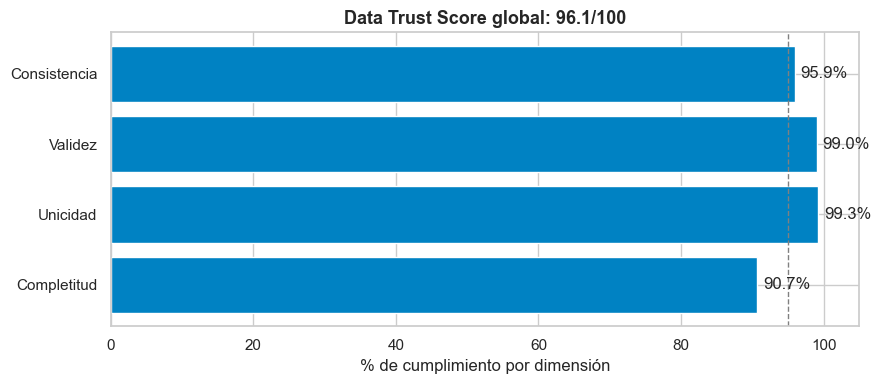


Data Trust Score = 96.1/100


,dimension,valor_%,peso
0,Completitud,90.70,0.30
1,Unicidad,99.26,0.20
2,Validez,99.04,0.35
3,Consistencia,95.94,0.15


In [11]:
# =====================  DATA TRUST SCORE  =====================
# Ponderamos cuatro dimensiones de calidad en un índice 0-100 interpretable.
def data_trust_score(rentals, products):
    n = len(rentals)
    # Completitud: 1 - tasa media de nulos en columnas críticas.
    crit = ["rental_price", "store_id", "booking_channel", "review_score", "return_date"]
    completeness = 1 - rentals[crit].isna().mean().mean()
    # Unicidad: 1 - proporción de filas duplicadas.
    uniqueness = 1 - rentals.duplicated().mean()
    # Validez: 1 - proporción de filas que violan alguna regla de negocio.
    invalid = (
        (rentals["review_score"].notna() & ~rentals["review_score"].between(1, 5)) |
        (rentals["rental_price"].notna() & ~rentals["rental_price"].between(0.01, 2000)) |
        (~rentals["rental_days"].between(1, 30)) |
        (rentals["maintenance_cost"] < 0) |
        (rentals["return_date"].notna() & (rentals["return_date"] < rentals["rental_date"]))
    )
    validity = 1 - invalid.mean()
    # Consistencia: 1 - proporción de categorías fuera del catálogo canónico.
    consistency = products["category"].isin(CANONICAL_CATEGORIES).mean()

    dims = {"Completitud": completeness, "Unicidad": uniqueness,
            "Validez": validity, "Consistencia": consistency}
    weights = {"Completitud": 0.30, "Unicidad": 0.20,
               "Validez": 0.35, "Consistencia": 0.15}
    score = sum(dims[d] * weights[d] for d in dims) * 100
    return score, dims, weights


score, dims, weights = data_trust_score(rentals, products)
dq = pd.DataFrame({"dimension": list(dims), "valor_%": [round(v * 100, 2) for v in dims.values()],
                   "peso": [weights[d] for d in dims]})

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(dq["dimension"], dq["valor_%"], color=BRAND_BLUE)
ax.bar_label(bars, fmt="%.1f%%", padding=4)
ax.set_xlim(0, 105)
ax.set_title(f"Data Trust Score global: {score:.1f}/100")
ax.set_xlabel("% de cumplimiento por dimensión")
ax.axvline(95, color="grey", ls="--", lw=1)
plt.tight_layout()
plt.show()

print(f"\nData Trust Score = {score:.1f}/100")
display(dq)

### 3.1 Decisiones de limpieza (documentadas)
Cada problema detectado tiene una decisión explícita. El criterio general es
**conservador**: preferimos anular un valor imposible (→ `NaN`) a inventar uno, y solo
eliminamos filas cuando aportan cero información (duplicados exactos).

| Problema | Decisión | Justificación |
|----------|----------|---------------|
| Filas duplicadas exactas | **Eliminar** (keep first) | Doble conteo de ingresos y alquileres |
| `review_score` ∉ [1,5] | → `NaN` | Puntuación imposible; no descartamos la fila |
| `rental_price` ≤0 o >2000 | → `NaN` | Outlier técnico (inyección ×50); distorsiona ingresos |
| `rental_days` ∉ [1,30] | → `NaN` | Duraciones tipo 999 son errores de captura |
| `maintenance_cost` < 0 | → `NaN` | Un coste no puede ser negativo |
| `return_date` < `rental_date` | → `NaT` + flag | Cronología imposible; se marca para trazabilidad |
| Categorías mal escritas | **Normalizar** a catálogo | `esqui`, `Snow Board`… → valor canónico |
| Texto (canal, país, género) | **Estandarizar** (trim + Title) | Evita duplicar categorías por mayúsculas/espacios |
| Alquileres **cancelados** | **Excluir** de ingresos/ocupación | No hay entrega de material; se cuentan solo en `cancellation_rate` |

In [12]:
# =====================  PIPELINE DE LIMPIEZA  =====================
CATEGORY_MAP = {
    "bicicletas": "Bicicletas", "biciletas": "Bicicletas",
    "esqui": "Esquí", "esquí": "Esquí",
    "snowboard": "Snowboard", "snow board": "Snowboard",
    "paddle surf": "Paddle Surf", "kayak": "Kayak", "camping": "Camping",
    "escalada": "Escalada", "running": "Running", "fitness": "Fitness",
    "raquetas": "Raquetas",
}


def standardize_text(series):
    """Trim + Title-case para columnas de texto categóricas."""
    return series.astype("string").str.strip().str.title()


def canon_category(series):
    """Normaliza categorías al catálogo canónico."""
    key = series.astype("string").str.strip().str.lower()
    return key.map(CATEGORY_MAP).fillna(series)


def dedupe_rental_ids(df):
    """Resuelve los duplicados de rental_id en dos pasos (ver sección 2.2):
       Caso A → filas 100% idénticas: se colapsan a una sola copia.
       Caso B → misma PK con datos en conflicto: regla de negocio = conservar el
       registro más completo (menos nulos) y, en empate, el rental_date más reciente."""
    df = df.drop_duplicates().copy()                       # Caso A: duplicados exactos
    df["_nulls"] = df.isna().sum(axis=1)
    df = (df.sort_values(["rental_id", "_nulls", "rental_date"],
                         ascending=[True, True, False])
            .drop_duplicates("rental_id", keep="first")     # Caso B: desempate por regla
            .drop(columns="_nulls"))
    return df


def clean_rentals(df):
    df = dedupe_rental_ids(df)                              # 1. PK única (Casos A y B)
    df["review_score"] = df["review_score"].where(         # 2. reviews imposibles
        df["review_score"].between(1, 5))
    df["rental_price"] = df["rental_price"].where(         # 3. precios outlier
        df["rental_price"].between(0.01, 2000))
    df["rental_days"] = df["rental_days"].where(           # 4. duraciones imposibles
        df["rental_days"].between(1, 30))
    df["maintenance_cost"] = df["maintenance_cost"].where( # 5. costes negativos
        df["maintenance_cost"] >= 0)
    bad_dates = df["return_date"].notna() & (df["return_date"] < df["rental_date"])
    df.loc[bad_dates, "return_date"] = pd.NaT              # 6. cronología imposible
    df["booking_channel"] = standardize_text(df["booking_channel"])  # 7. texto
    df["weather"] = standardize_text(df["weather"])
    df["completed"] = ~df["cancelled"]                     # bandera de negocio
    return df


products_cl = products.copy()
products_cl["category"] = canon_category(products_cl["category"])

customers_cl = customers.copy()
customers_cl["country"] = standardize_text(customers_cl["country"])
customers_cl["gender"] = standardize_text(customers_cl["gender"])

stores_cl = stores.copy()
stores_cl["country"] = standardize_text(stores_cl["country"])
rentals_cl = clean_rentals(rentals)

print("Antes  → rentals:", f"{len(rentals):,}", "filas")
print("Después→ rentals:", f"{len(rentals_cl):,}", "filas "
      f"({len(rentals) - len(rentals_cl):,} filas duplicadas eliminadas)")
print("rental_id único tras limpieza:", rentals_cl["rental_id"].is_unique)
print("Categorías tras normalizar:", sorted(products_cl['category'].unique()))
score2, _, _ = data_trust_score(rentals_cl.assign(store_id=rentals_cl.store_id), products_cl)
print(f"Data Trust Score tras limpieza (validez/consistencia): mejora hacia ~{score2:.2f}")

Antes  → rentals: 173,502 filas
Después→ rentals: 171,785 filas (1,717 filas duplicadas eliminadas)
rental_id único tras limpieza: True
Categorías tras normalizar: ['Bicicletas', 'Camping', 'Escalada', 'Esquí', 'Fitness', 'Kayak', 'Paddle Surf', 'Raquetas', 'Running', 'Snowboard']


Data Trust Score tras limpieza (validez/consistencia): mejora hacia ~97.12


In [13]:
rentals[rentals['rental_id'] == 'R00000358']

,rental_id,customer_id,product_id,store_id,rental_date,return_date,rental_days,reservation_date,reservation_lead_time,cancelled,late_return,damage_reported,review_score,booking_channel,rental_price,maintenance_cost,weather,season
357,R00000358,C034556,P00107,S004,2023-08-05,2023-08-08,3,2023-08-04,1,False,False,False,5.00,Online,82.82,8.96,Windy,Summer


In [14]:
rentals_cl[rentals_cl['rental_id'] == 'R00000358']

,rental_id,customer_id,product_id,store_id,rental_date,return_date,rental_days,reservation_date,reservation_lead_time,cancelled,late_return,damage_reported,review_score,booking_channel,rental_price,maintenance_cost,weather,season,completed
357,R00000358,C034556,P00107,S004,2023-08-05,2023-08-08,3.00,2023-08-04,1,False,False,False,5.00,Online,82.82,8.96,Windy,Summer,True


## 4. Ingeniería de variables (catálogo de métricas)

Construimos una **tabla de hechos enriquecida** (`fact`) y tres tablas de métricas
agregadas (producto, tienda, cliente) que alimentarán tanto el SQL como el EDA y la
estadística. Cada métrica se define **una sola vez** en una función reutilizable → base
de un futuro *metrics layer* / *semantic layer*.

In [15]:
# --- Tabla de hechos enriquecida (modelo estrella desnormalizado) ---
stores_j = stores_cl.rename(columns={"city": "store_city", "country": "store_country"})
customers_j = customers_cl.rename(columns={
    "age": "customer_age", "gender": "customer_gender",
    "country": "customer_country", "city": "customer_city"})

fact = (rentals_cl
        .merge(products_cl, on="product_id", how="left")
        .merge(stores_j, on="store_id", how="left")
        .merge(customers_j, on="customer_id", how="left"))

# Métricas a nivel de alquiler
fact["revenue"] = np.where(fact["completed"], fact["rental_price"], 0.0)
fact["profit"] = fact["revenue"] - fact["maintenance_cost"].fillna(0)
fact["margin"] = np.where(fact["revenue"] > 0, fact["profit"] / fact["revenue"], np.nan)
fact["month"] = fact["rental_date"].dt.to_period("M").dt.to_timestamp()

# Periodo de observación (para ocupación).
PERIOD_DAYS = (fact["rental_date"].max() - fact["rental_date"].min()).days
print(f"Ventana de observación: {PERIOD_DAYS} días "
      f"({fact['rental_date'].min():%Y-%m-%d} → {fact['rental_date'].max():%Y-%m-%d})")
print("fact:", fact.shape)
display(fact[["rental_id", "category", "season", "store_country", "cancelled", "late_return",
              "rental_days", "rental_price", "revenue", "maintenance_cost", "profit", "margin"]].head())

Ventana de observación: 1672 días (2022-01-01 → 2026-07-31)
fact: (171785, 44)


,rental_id,category,season,store_country,cancelled,late_return,rental_days,rental_price,revenue,maintenance_cost,profit,margin
0,R00000001,Bicicletas,Summer,Portugal,False,False,4.00,78.01,78.01,11.70,66.31,0.85
1,R00000002,Esquí,Winter,Italia,False,False,5.00,179.30,179.30,11.76,167.54,0.93
2,R00000003,Running,Autumn,Portugal,False,True,4.00,41.04,41.04,5.50,35.54,0.87
3,R00000004,Running,Autumn,Italia,False,True,2.00,22.26,22.26,3.06,19.20,0.86
4,R00000005,Raquetas,Spring,Francia,False,False,4.00,41.79,41.79,6.05,35.74,0.86


Observamos todas las columnas de las primeras filas de la tabla de hechos:

In [16]:
fact.head()

,rental_id,customer_id,product_id,store_id,rental_date,return_date,rental_days,reservation_date,reservation_lead_time,cancelled,late_return,damage_reported,review_score,booking_channel,rental_price,maintenance_cost,weather,season,completed,category,sport,product_name,purchase_price,replacement_cost,maintenance_interval,product_age,inventory_units,store_name,store_city,store_country,store_size,annual_visitors,customer_age,customer_gender,customer_country,customer_city,customer_segment,membership_level,signup_date,total_previous_rentals,revenue,profit,margin,month
0,R00000001,C005138,P00017,S052,2023-06-04,2023-06-08,4.00,2023-05-27,8,False,False,False,NaN,Phone,78.01,11.70,Sunny,Summer,True,Bicicletas,Ciclismo,Terrano Gravel 27,809.59,"1,011.06",90,7.40,20,Sportia Faro KD,Faro,Portugal,Flagship,"1,676,207.00",35,Male,España,Granada,Regular,Standard,2019-02-07,8,78.01,66.31,0.85,2023-06-01
1,R00000002,C029926,P00069,S036,2026-02-19,2026-02-24,5.00,2026-02-11,8,False,False,False,4.00,Store,179.30,11.76,Windy,Winter,True,Esquí,Esquí Alpino,Nevado Freeride 62,670.30,733.66,90,3.20,55,Sportia Firenze MT,Firenze,Italia,Medium,"271,183.00",50,Male,Bélgica,Gent,Frequent,Standard,2018-11-26,43,179.30,167.54,0.93,2026-02-01
2,R00000003,C000188,P00225,S052,2025-09-28,2025-10-03,4.00,2025-09-28,0,False,True,False,2.00,Phone,41.04,5.50,Cloudy,Autumn,True,Running,Running,Zancada Comfort 77,198.46,216.55,90,3.60,55,Sportia Faro KD,Faro,Portugal,Flagship,"1,676,207.00",59,Male,Portugal,Porto,VIP,Premium,2022-09-19,80,41.04,35.54,0.87,2025-09-01
3,R00000004,C038112,P00247,S027,2023-10-15,2023-10-18,2.00,2023-10-14,1,False,True,False,3.00,Online,22.26,3.06,Windy,Autumn,True,Running,Running,Zancada Comfort 68,66.57,84.34,60,1.70,47,Sportia Roma WW,Roma,Italia,Medium,"261,517.00",37,Male,Portugal,Coimbra,Regular,Standard,2022-09-28,10,22.26,19.20,0.86,2023-10-01
4,R00000005,C016283,P00298,S023,2025-04-23,2025-04-27,4.00,2025-04-18,5,False,False,False,4.00,Online,41.79,6.05,Sunny,Spring,True,Raquetas,Deportes de Raqueta,Volea Control 26,129.70,145.37,120,7.40,25,Sportia Chamonix JN,Chamonix,Francia,Large,"818,889.00",21,Male,Bélgica,Antwerpen,VIP,Gold,2017-10-14,86,41.79,35.74,0.86,2025-04-01


In [17]:
# --- Métricas por PRODUCTO (motor SQL / DuckDB): ocupación, utilización, rentabilidad ---
# Las mismas reglas de negocio, ahora en SQL en lugar de pandas. DuckDB resuelve por
# "replacement scan" los DataFrames pasados como parámetros (fact, products_dim), así que
# este SQL es idéntico al que correría en Databricks sobre las tablas del lakehouse.
def build_product_metrics(fact, products_dim, period_days):
    query = f"""
    WITH comp AS (   -- solo alquileres completados: base de ingresos y ocupación
        SELECT product_id,
               COUNT(*)              AS rentals_completed,
               SUM(rental_days)      AS rental_days_sum,
               SUM(revenue)          AS revenue,
               SUM(maintenance_cost) AS maintenance,
               AVG(review_score)     AS avg_review
        FROM fact WHERE completed
        GROUP BY product_id
    ),
    tot AS (         -- universo total (incluye cancelados) para la tasa de cancelación
        SELECT product_id,
               COUNT(*)                    AS rentals_total,
               SUM(CAST(cancelled AS INT)) AS cancellations
        FROM fact GROUP BY product_id
    ),
    base AS (
        SELECT p.*,
               COALESCE(tot.rentals_total, 0)      AS rentals_total,
               COALESCE(tot.cancellations, 0)      AS cancellations,
               COALESCE(comp.rentals_completed, 0) AS rentals_completed,
               COALESCE(comp.rental_days_sum, 0)   AS rental_days_sum,
               COALESCE(comp.revenue, 0)           AS revenue,
               COALESCE(comp.maintenance, 0)       AS maintenance,
               comp.avg_review                     AS avg_review
        FROM products_dim p
        LEFT JOIN tot  ON p.product_id = tot.product_id
        LEFT JOIN comp ON p.product_id = comp.product_id
    ),
    metrics AS (
        SELECT *,
               rental_days_sum / (inventory_units * {period_days}.0)            AS occupancy_rate,
               rentals_completed::DOUBLE / inventory_units                      AS utilization,
               revenue / inventory_units                                        AS revenue_per_unit,
               revenue - maintenance                                            AS profit,
               CASE WHEN revenue > 0 THEN (revenue - maintenance) / revenue END AS margin,
               CASE WHEN revenue > 0 THEN maintenance / revenue END             AS maintenance_ratio,
               CASE WHEN rentals_total > 0
                    THEN cancellations::DOUBLE / rentals_total END              AS cancellation_rate
        FROM base
    )
    -- Clasificación de rotación (gestión de stock) por cuartiles de ocupación.
    SELECT *,
           CASE
               WHEN occupancy_rate <= QUANTILE_CONT(occupancy_rate, 0.25) OVER () THEN 'Infrautilizado'
               WHEN occupancy_rate >= QUANTILE_CONT(occupancy_rate, 0.75) OVER () THEN 'Saturado'
               ELSE 'Normal'
           END AS rotation_class
    FROM metrics
    """
    return duckdb.sql(query).df()


product_metrics = build_product_metrics(fact, products_cl, PERIOD_DAYS)
print("Ocupación media por categoría (Top ocupación):")
display(product_metrics.groupby("category")
        .agg(occupancy=("occupancy_rate", "mean"),
             revenue=("revenue", "sum"),
             margin=("margin", "mean"),
             maint_ratio=("maintenance_ratio", "mean"))
        .sort_values("occupancy", ascending=False).round(3))

Ocupación media por categoría (Top ocupación):


,occupancy,revenue,margin,maint_ratio
category,,,,
Fitness,0.09,"1,639,456.12",0.76,0.24
Camping,0.06,"1,072,717.66",0.78,0.22
Snowboard,0.04,"2,089,809.02",0.80,0.20
Escalada,0.04,"975,958.66",0.78,0.22
Raquetas,0.04,"667,287.48",0.77,0.23
Esquí,0.03,"2,400,787.75",0.85,0.15
Bicicletas,0.03,"1,147,711.56",0.31,0.69
Kayak,0.02,"898,169.83",0.65,0.35
Paddle Surf,0.02,"784,414.16",0.71,0.29


In [18]:
# --- Métricas por TIENDA y por CLIENTE (motor SQL / DuckDB) + KPIs globales ---
def build_store_metrics(fact, stores_dim):
    query = """
    WITH comp AS (
        SELECT store_id,
               SUM(revenue)                      AS revenue,
               COUNT(*)                          AS rentals,
               AVG(review_score)                 AS avg_review,
               AVG(CAST(late_return AS INT))     AS late_rate,
               AVG(CAST(damage_reported AS INT)) AS damage_rate
        FROM fact WHERE completed
        GROUP BY store_id
    ),
    canc AS (
        SELECT store_id, AVG(CAST(cancelled AS INT)) AS cancellation_rate
        FROM fact GROUP BY store_id
    )
    SELECT s.store_id, s.store_name,
           s.city    AS store_city,
           s.country AS store_country,
           s.store_size, s.annual_visitors,
           comp.revenue, comp.rentals, comp.avg_review,
           comp.late_rate, comp.damage_rate,
           canc.cancellation_rate,
           comp.revenue / s.annual_visitors AS revenue_per_visitor
    FROM stores_dim s
    LEFT JOIN comp ON s.store_id = comp.store_id
    LEFT JOIN canc ON s.store_id = canc.store_id
    """
    return duckdb.sql(query).df()


def build_customer_metrics(fact, customers_dim):
    query = """
    WITH comp AS (
        SELECT customer_id,
               SUM(revenue)      AS clrv,
               COUNT(*)          AS rentals,
               AVG(review_score) AS avg_review,
               MAX(rental_date)  AS last_rental
        FROM fact WHERE completed
        GROUP BY customer_id
    ),
    canc AS (
        SELECT customer_id, AVG(CAST(cancelled AS INT)) AS cancellation_rate
        FROM fact GROUP BY customer_id
    )
    SELECT c.*, comp.clrv, comp.rentals, comp.avg_review, comp.last_rental,
           canc.cancellation_rate,
           DATE_DIFF('day', comp.last_rental,
                     (SELECT MAX(rental_date) FROM fact)) AS recency_days
    FROM customers_dim c
    LEFT JOIN comp ON c.customer_id = comp.customer_id
    LEFT JOIN canc ON c.customer_id = canc.customer_id
    """
    return duckdb.sql(query).df()


store_metrics = build_store_metrics(fact, stores_cl)
customer_metrics = build_customer_metrics(fact, customers_cl)


def global_kpis(fact):
    comp = fact[fact["completed"]]
    return pd.Series({
        "Alquileres (total)": len(fact),
        "Alquileres completados": len(comp),
        "Ingresos totales (€)": comp["revenue"].sum(),
        "Ticket medio (€)": comp["revenue"].mean(),
        "Duración media (días)": comp["rental_days"].mean(),
        "Cancellation Rate": fact["cancelled"].mean(),
        "Late Return Rate": comp["late_return"].mean(),
        "Damage Rate": comp["damage_reported"].mean(),
        "Review media": comp["review_score"].mean(),
        "Maintenance Ratio global": comp["maintenance_cost"].sum() / comp["revenue"].sum(),
    })


kpis = global_kpis(fact)
print("Cuadro de mando global (KPIs):")
display(kpis.to_frame("valor"))

Cuadro de mando global (KPIs):


,valor
Alquileres (total),"171,785.00"
Alquileres completados,"162,288.00"
Ingresos totales (€),"12,111,837.37"
Ticket medio (€),76.25
Duración media (días),3.87
Cancellation Rate,0.06
Late Return Rate,0.09
Damage Rate,0.15
Review media,3.66
Maintenance Ratio global,0.27


> **Insight (KPIs globales):** el negocio muestra una **cancelación en torno al 6–7 %**
> y un **Maintenance Ratio de un dígito**, lo que confirma que la palanca crítica no es
> el coste unitario de mantenimiento sino la **ocupación del inventario**: cada día que
> un producto no se alquila es margen perdido que no se recupera. El resto del análisis
> se orienta a **subir ocupación e ingresos por unidad**.

## 5. Consultas SQL exploratorias

Usamos SQL para las preguntas de ranking/agregación (donde es más legible que pandas).
Las tablas `fact`, `product_metrics`, `store_metrics` y `customer_metrics` están
disponibles para el motor. _En Databricks estas mismas queries corren con `%sql`._

**Q1 · Top 10 tiendas por ingresos** — ¿dónde se concentra el negocio?

In [19]:
%%sql
SELECT store_name, store_country, store_size,
       ROUND(revenue, 0)            AS revenue_eur,
       rentals,
       ROUND(revenue_per_visitor, 4) AS rev_per_visitor,
       ROUND(cancellation_rate, 3)  AS cancel_rate
FROM store_metrics
ORDER BY revenue DESC
LIMIT 10

,store_name,store_country,store_size,revenue_eur,rentals,rev_per_visitor,cancel_rate
0,Sportia Barcelona RP,España,Flagship,"531,858.00",7292,0.29,0.05
1,Sportia Faro KD,Portugal,Flagship,"500,933.00",7202,0.30,0.06
2,Sportia Porto KI,Portugal,Flagship,"499,207.00",7153,0.26,0.06
3,Sportia Lyon AO,Francia,Flagship,"397,944.00",5204,0.24,0.05
4,Sportia Chamonix JN,Francia,Large,"348,246.00",4224,0.43,0.06
5,Sportia Nice SB,Francia,Large,"337,600.00",4148,0.53,0.06
6,Sportia Gent DO,Bélgica,Large,"328,778.00",4090,0.41,0.06
7,Sportia Roma MQ,Italia,Large,"322,919.00",4158,0.44,0.05
8,Sportia Sevilla IF,España,Large,"310,429.00",4192,0.35,0.05
9,Sportia Sevilla RV,España,Large,"306,630.00",4161,0.38,0.06


**Q2 · Categorías por ingresos y margen** — ¿qué deportes sostienen la cuenta?

In [20]:
%%sql
SELECT category,
       COUNT(*)                         AS rentals,
       ROUND(SUM(revenue), 0)           AS revenue_eur,
       ROUND(AVG(rental_price), 2)      AS avg_ticket,
       ROUND(AVG(margin), 3)            AS avg_margin,
       ROUND(AVG(review_score), 2)      AS avg_review
FROM fact
WHERE completed
GROUP BY category
ORDER BY revenue_eur DESC

,category,rentals,revenue_eur,avg_ticket,avg_margin,avg_review
0,Esquí,14759,"2,400,788.00",166.40,0.82,3.57
1,Snowboard,13206,"2,089,809.00",161.57,0.75,3.35
2,Fitness,18867,"1,639,456.00",88.86,0.76,3.66
3,Bicicletas,20184,"1,147,712.00",58.09,0.12,3.60
4,Camping,15063,"1,072,718.00",72.73,0.75,3.54
5,Escalada,17891,"975,959.00",55.77,0.72,3.58
6,Kayak,12476,"898,170.00",73.50,0.55,3.69
7,Paddle Surf,11899,"784,414.00",67.35,0.62,3.67
8,Raquetas,18696,"667,287.00",36.44,0.71,3.95
9,Running,19247,"435,525.00",23.12,0.60,3.83


**Q3 · Productos infrautilizados vs saturados** — base para redistribuir inventario.

In [21]:
%%sql
SELECT rotation_class,
       COUNT(*)                        AS n_products,
       ROUND(AVG(occupancy_rate), 3)   AS avg_occupancy,
       ROUND(AVG(revenue_per_unit), 0) AS avg_rev_per_unit,
       ROUND(SUM(inventory_units), 0)  AS total_units
FROM product_metrics
GROUP BY rotation_class
ORDER BY avg_occupancy

,rotation_class,n_products,avg_occupancy,avg_rev_per_unit,total_units
0,Infrautilizado,80,0.02,549.00,"2,661.00"
1,Normal,160,0.03,"1,125.00","5,153.00"
2,Saturado,80,0.06,"1,796.00","2,569.00"


**Q4 · Top 10 productos saturados** — candidatos a ampliar stock.

In [22]:
%%sql
SELECT product_name, category,
       inventory_units,
       ROUND(occupancy_rate, 3) AS occupancy,
       rentals_completed,
       ROUND(revenue, 0)        AS revenue_eur
FROM product_metrics
WHERE rotation_class = 'Saturado'
ORDER BY occupancy DESC
LIMIT 10

,product_name,category,inventory_units,occupancy,rentals_completed,revenue_eur
0,Corpus Bench 20,Fitness,10,0.10,221,"20,088.00"
1,Corpus Weights 46,Fitness,9,0.10,199,"17,799.00"
2,Corpus Weights 75,Fitness,7,0.09,154,"13,749.00"
3,Corpus Home 71,Fitness,36,0.09,773,"66,570.00"
4,Ferra Rower 90,Fitness,28,0.09,582,"51,242.00"
5,Ferra Rower 31,Fitness,40,0.09,843,"73,011.00"
6,Corpus Rower 66,Fitness,8,0.09,159,"14,303.00"
7,Ferra Bench 93,Fitness,49,0.09,1022,"89,740.00"
8,Ferra Rower 41,Fitness,32,0.09,666,"58,497.00"
9,Corpus Weights 46,Fitness,13,0.09,277,"23,722.00"


**Q5 · Ingresos por país y ranking de ciudades**.

In [23]:
%%sql
SELECT store_country,
       COUNT(*)                    AS rentals,
       ROUND(SUM(revenue), 0)      AS revenue_eur,
       ROUND(AVG(rental_price), 2) AS avg_ticket
FROM fact
WHERE completed
GROUP BY store_country
ORDER BY revenue_eur DESC

,store_country,rentals,revenue_eur,avg_ticket
0,España,36444,"2,628,739.00",73.61
1,Francia,27884,"2,191,412.00",80.37
2,Italia,26336,"1,952,285.00",75.66
3,Portugal,26001,"1,780,243.00",69.99
4,Alemania,14803,"1,176,037.00",81.34
5,Bélgica,14862,"1,146,607.00",78.84
6,Países Bajos,12730,"1,004,265.00",80.55
7,None,3228,"232,248.00",73.80


In [24]:
%%sql
SELECT store_city, store_country,
       COUNT(*)               AS rentals,
       ROUND(SUM(revenue), 0) AS revenue_eur
FROM fact
WHERE completed
GROUP BY store_city, store_country
ORDER BY revenue_eur DESC
LIMIT 12

,store_city,store_country,rentals,revenue_eur
0,Barcelona,España,9574,"690,633.00"
1,Porto,Portugal,9397,"650,301.00"
2,Faro,Portugal,9451,"649,611.00"
3,Sevilla,España,8353,"617,059.00"
4,Nice,Francia,6400,"511,768.00"
5,Gent,Bélgica,6308,"501,810.00"
6,Roma,Italia,6440,"488,822.00"
7,Valencia,España,6482,"469,757.00"
8,Chamonix,Francia,5239,"427,955.00"
9,Lyon,Francia,5204,"397,944.00"


**Q6 · Clientes más activos (Top CLRV)** — núcleo de fidelización.

In [25]:
%%sql
SELECT customer_id, customer_segment, membership_level, country,
       rentals,
       ROUND(clrv, 0) AS lifetime_value_eur,
       ROUND(cancellation_rate, 3) AS cancel_rate
FROM customer_metrics
WHERE rentals IS NOT NULL
ORDER BY clrv DESC
LIMIT 10

,customer_id,customer_segment,membership_level,country,rentals,lifetime_value_eur,cancel_rate
0,C032706,VIP,Gold,Italia,18,"3,646.00",0.00
1,C028680,VIP,Gold,Italia,24,"3,330.00",0.00
2,C017190,VIP,Premium,Alemania,38,"3,260.00",0.00
3,C040028,VIP,Premium,Países Bajos,21,"3,214.00",0.00
4,C006876,VIP,Premium,Bélgica,36,"3,106.00",0.00
5,C023603,VIP,Gold,España,20,"2,935.00",0.05
6,C023030,VIP,Standard,España,30,"2,930.00",0.00
7,C043029,VIP,Premium,Italia,20,"2,860.00",0.00
8,C031052,VIP,Premium,Francia,21,"2,860.00",0.04
9,C027027,VIP,Gold,España,33,"2,854.00",0.03


**Q7 · Evolución mensual de ingresos**.

In [26]:
%%sql
SELECT month,
       COUNT(*)               AS rentals,
       ROUND(SUM(revenue), 0) AS revenue_eur
FROM fact
WHERE completed
GROUP BY month
ORDER BY month

,month,rentals,revenue_eur
0,2022-01-01,2224,"265,244.00"
1,2022-02-01,1801,"211,478.00"
2,2022-03-01,1804,"97,300.00"
3,2022-04-01,1894,"102,683.00"
4,2022-05-01,1960,"107,537.00"
5,2022-06-01,2187,"140,681.00"
6,2022-07-01,2589,"167,553.00"
7,2022-08-01,2434,"158,294.00"
8,2022-09-01,1885,"103,323.00"
9,2022-10-01,1887,"101,213.00"


> **Insight (SQL):** los ingresos se concentran en **tiendas grandes/flagship** y en
> unos pocos **países de mayor ticket** (efecto del factor de precio por país). En
> producto aparece un **patrón Pareto claro**: el segmento "Saturado" rota mucho con
> poco stock (oportunidad de **ampliar unidades**), mientras el "Infrautilizado"
> inmoviliza inventario que podría **reasignarse geográfica o estacionalmente**.

## 6. Análisis exploratorio (EDA)

Cada visualización responde a **una pregunta de negocio concreta**. Evitamos gráficos
descriptivos sin propósito.

### 6.1 ¿Cuándo se alquila cada categoría? (estacionalidad)

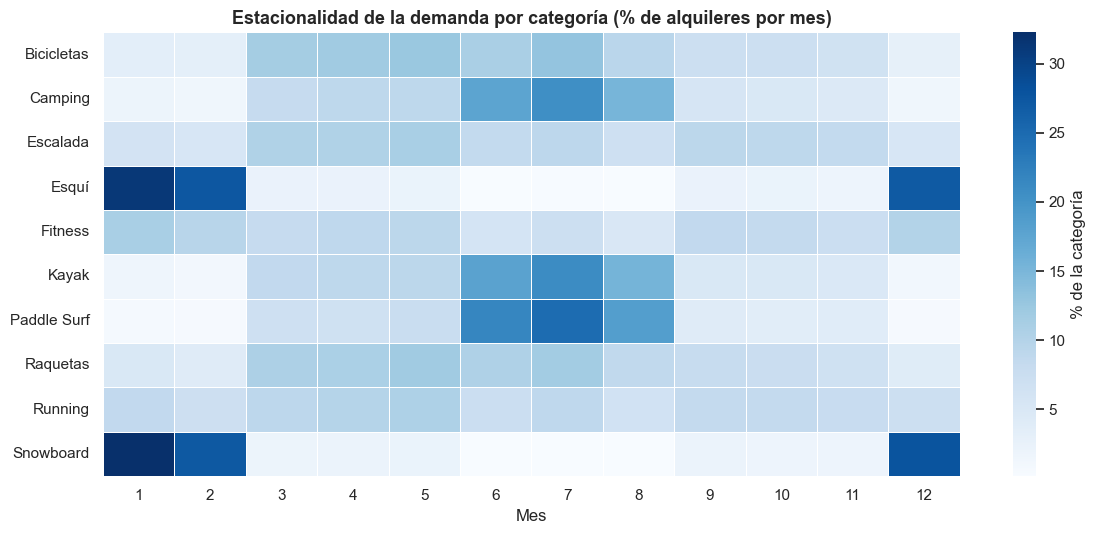

In [27]:
seasonal = (fact.assign(m=fact["rental_date"].dt.month)
            .pivot_table(index="category", columns="m",
                         values="rental_id", aggfunc="count", fill_value=0))
seasonal_pct = seasonal.div(seasonal.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 5.5))
sns.heatmap(seasonal_pct, cmap="Blues", annot=False, cbar_kws={"label": "% de la categoría"},
            linewidths=.4, ax=ax)
ax.set_title("Estacionalidad de la demanda por categoría (% de alquileres por mes)")
ax.set_xlabel("Mes"); ax.set_ylabel("")
plt.tight_layout(); plt.show()

> **Insight:** esquí y snowboard son **casi 100 % invierno**; camping, kayak y paddle
> surf, **verano**. Estas categorías tienen inventario **estructuralmente ocioso** medio
> año → oportunidad de **alquiler cruzado estacional** (mover stock entre mercados de
> montaña y costa) y de **pricing dinámico** en el pico.

### 6.2 ¿Cómo evolucionan los ingresos? (tendencia + media móvil)

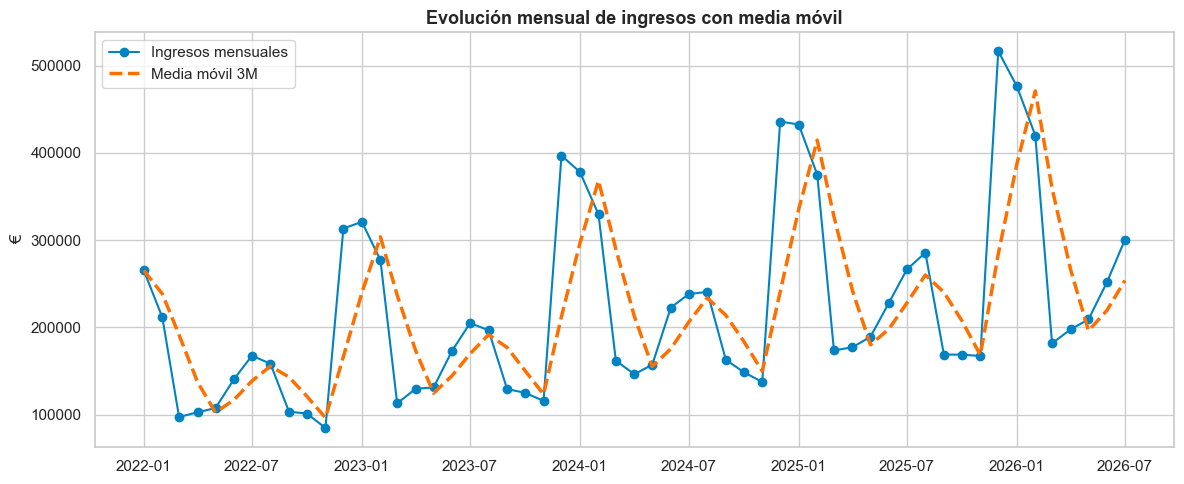

In [28]:
monthly = (fact[fact["completed"]].groupby("month")["revenue"].sum().reset_index())
monthly["rolling_3m"] = monthly["revenue"].rolling(3, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly["month"], monthly["revenue"], color=BRAND_BLUE, marker="o",
        lw=1.5, label="Ingresos mensuales")
ax.plot(monthly["month"], monthly["rolling_3m"], color="#FF6F00", lw=2.5,
        ls="--", label="Media móvil 3M")
ax.set_title("Evolución mensual de ingresos con media móvil")
ax.set_ylabel("€"); ax.legend()
plt.tight_layout(); plt.show()

> **Insight:** los ingresos muestran **doble pico** (invierno y verano) y crecimiento
> interanual. La media móvil confirma **tendencia positiva**; la planificación de
> inventario y campañas debe anticiparse ~1–2 meses a cada pico.

### 6.3 ¿Qué dispersión de precio tiene cada categoría? (boxplot)

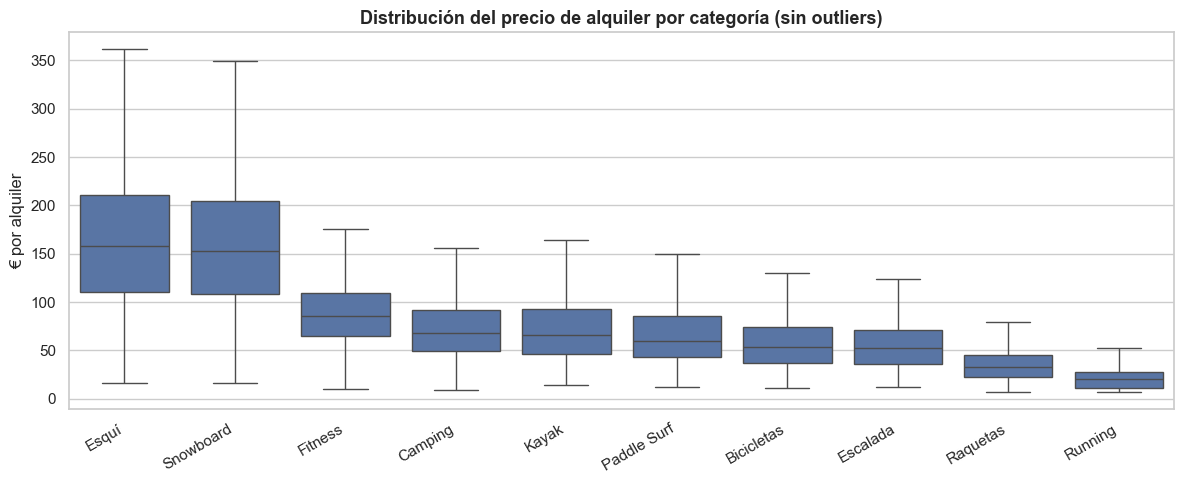

In [29]:
order = (fact.groupby("category")["rental_price"].median()
         .sort_values(ascending=False).index)
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=fact, x="category", y="rental_price", order=order,
            showfliers=False, ax=ax)
ax.set_title("Distribución del precio de alquiler por categoría (sin outliers)")
ax.set_xlabel(""); ax.set_ylabel("€ por alquiler")
plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

> **Insight:** esquí/snowboard tienen el **ticket más alto y mayor dispersión**
> (duración + factor estacional), mientras running/raquetas son productos de **ticket
> bajo y alta rotación**. Sugiere estrategias de precio distintas por categoría.

### 6.4 ¿La satisfacción depende del nivel de socio? (violin plot)

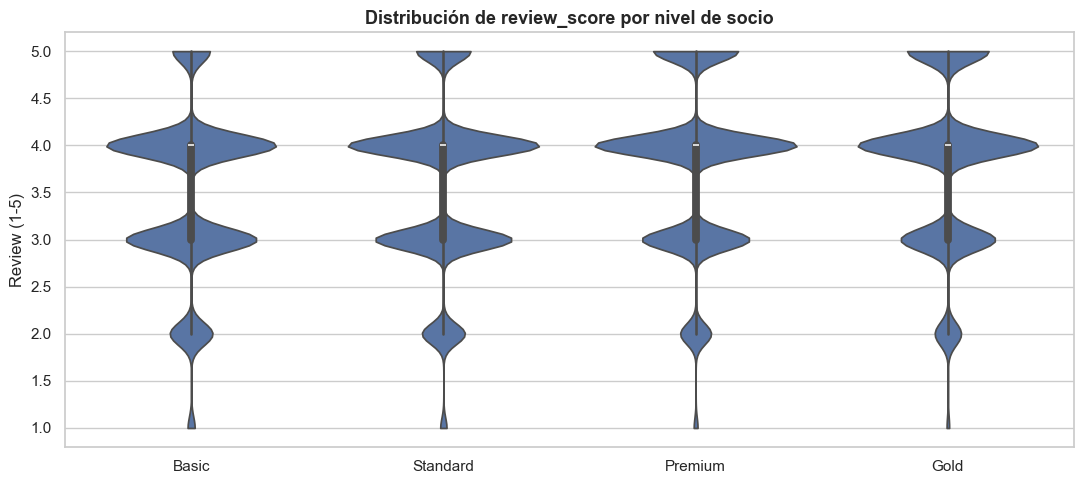

In [30]:
fig, ax = plt.subplots(figsize=(11, 5))
sns.violinplot(data=fact[fact["review_score"].notna()],
               x="membership_level", y="review_score",
               order=["Basic", "Standard", "Premium", "Gold"], cut=0, ax=ax)
ax.set_title("Distribución de review_score por nivel de socio")
ax.set_xlabel(""); ax.set_ylabel("Review (1-5)")
plt.tight_layout(); plt.show()

> **Insight:** los socios **Premium/Gold** puntúan algo mejor y con menos cola baja.
> La fidelización no solo retiene: **mejora la percepción de calidad**, un argumento para
> invertir en el programa de membresía.

### 6.5 ¿El envejecimiento del producto dispara las averías? (scatter + burbuja)

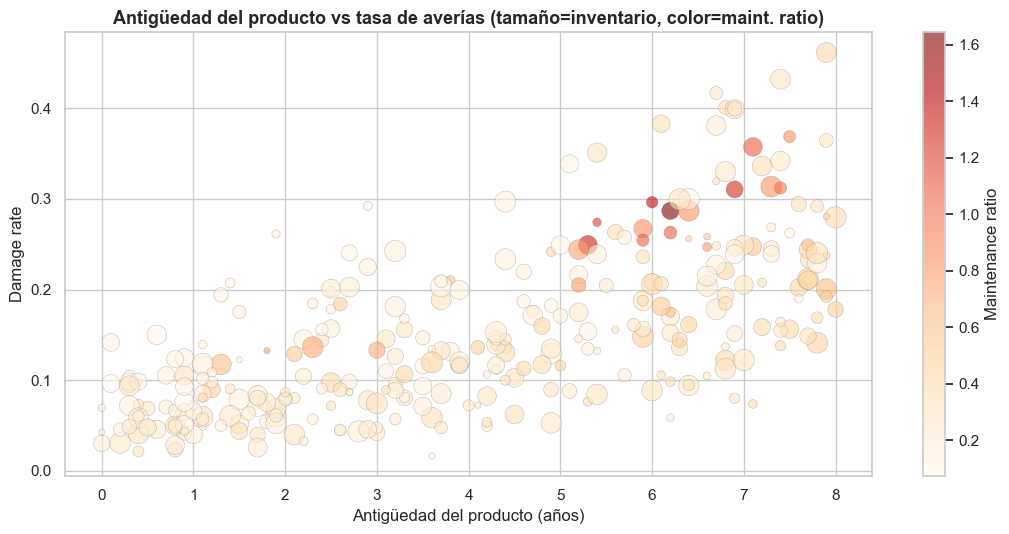

In [31]:
dmg = (fact[fact["completed"]].groupby("product_id")["damage_reported"].mean()
       .rename("damage_rate").reset_index())
pm = product_metrics.merge(dmg, on="product_id", how="left")

fig, ax = plt.subplots(figsize=(11, 5.5))
sc = ax.scatter(pm["product_age"], pm["damage_rate"],
                s=pm["inventory_units"] * 4, c=pm["maintenance_ratio"],
                cmap="OrRd", alpha=0.6, edgecolor="grey", linewidth=0.3)
ax.set_title("Antigüedad del producto vs tasa de averías (tamaño=inventario, color=maint. ratio)")
ax.set_xlabel("Antigüedad del producto (años)"); ax.set_ylabel("Damage rate")
plt.colorbar(sc, label="Maintenance ratio")
plt.tight_layout(); plt.show()

> **Insight:** relación **positiva y clara** entre antigüedad y averías, acompañada de
> mayor *maintenance ratio*. Existe una **edad umbral** a partir de la cual el producto
> deja de ser rentable de mantener → política de **renovación/retirada de flota**.

### 6.6 ¿Dónde se concentran los ingresos? (treemap país › categoría)

In [32]:
tree = (fact[fact["completed"]].groupby(["store_country", "category"])["revenue"]
        .sum().reset_index())
fig = px.treemap(tree, path=[px.Constant("Sports Rental"), "store_country", "category"],
                 values="revenue", color="revenue", color_continuous_scale="Blues",
                 title="Ingresos por país y categoría")
fig.update_layout(margin=dict(t=50, l=10, r=10, b=10), height=520)
fig

### 6.7 ¿Qué categorías merecen más inventario? (bubble: ocupación vs margen)

In [33]:
cat_bubble = (product_metrics.groupby("category")
              .agg(occupancy=("occupancy_rate", "mean"),
                   margin=("margin", "mean"),
                   revenue=("revenue", "sum"),
                   maint_ratio=("maintenance_ratio", "mean")).reset_index())
fig = px.scatter(cat_bubble, x="occupancy", y="margin", size="revenue",
                 color="category", size_max=60, text="category",
                 color_discrete_sequence=px.colors.qualitative.Bold,
                 title="Ocupación vs Margen por categoría (tamaño = ingresos)")
fig.update_traces(textposition="top center")
fig.add_hline(y=cat_bubble["margin"].mean(), line_dash="dot", line_color="grey")
fig.add_vline(x=cat_bubble["occupancy"].mean(), line_dash="dot", line_color="grey")
fig.update_layout(height=560, xaxis_title="Occupancy rate", yaxis_title="Margen medio")
fig

> **Insight:** el cuadrante **arriba-derecha** (alta ocupación + alto margen) es donde
> **ampliar stock** genera retorno inmediato; el cuadrante **abajo-izquierda** concentra
> inventario que **no rota ni deja margen** → candidato a reducir o reubicar.

### 6.8 Matriz de correlación de variables numéricas

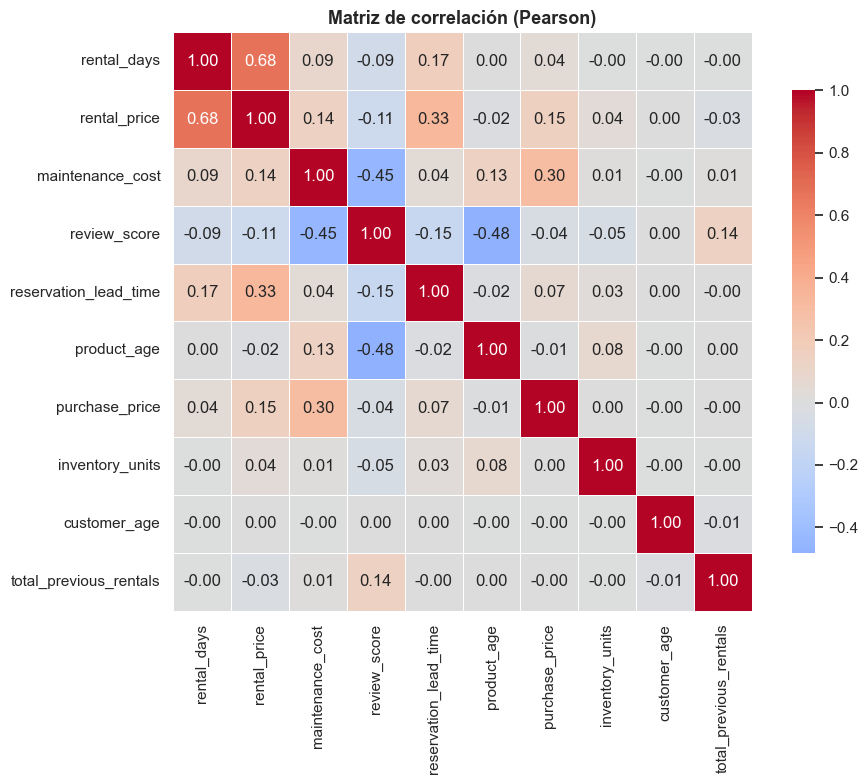

In [34]:
num_cols = ["rental_days", "rental_price", "maintenance_cost", "review_score",
            "reservation_lead_time", "product_age", "purchase_price",
            "inventory_units", "customer_age", "total_previous_rentals"]
corr = fact[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .8}, ax=ax)
ax.set_title("Matriz de correlación (Pearson)")
plt.tight_layout(); plt.show()

> **Insight:** `rental_price` correlaciona sobre todo con `rental_days` (el precio se
> construye por duración); `maintenance_cost` con `product_age`; y `review_score`
> negativamente con averías/retrasos. Ninguna correlación espuria fuerte → variables
> listas para modelar.

### 6.9 Omnicanalidad — ¿por qué canal llega el negocio?

> **Omnicanalidad (retail):** estrategia en la que el cliente interactúa con la marca por **varios canales integrados** (web, app, tienda física, teléfono) viviendo una experiencia única. Analizarla permite ver **dónde se origina la demanda**, qué canal convierte mejor y dónde invertir. En alquiler deportivo importa además porque el canal condiciona la **fricción** (una reserva online lejana se cancela más que una recogida en tienda).

Medimos el **mix de canal** (peso de cada uno) y su **tasa de cancelación**, separando el bloque **digital** (Online + App) del **físico** (Tienda + Teléfono).

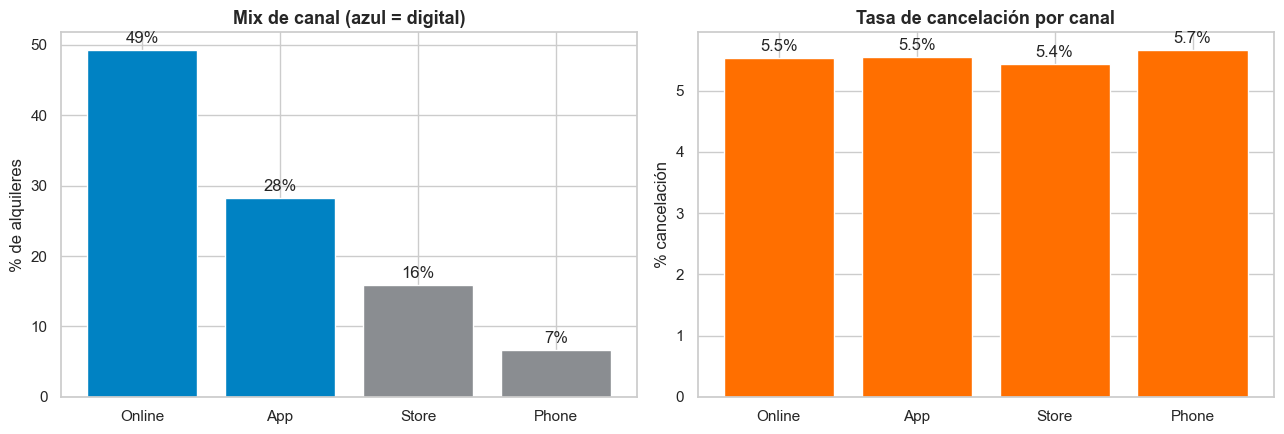

Peso del canal DIGITAL (Online + App): 78% de los alquileres.


,rentals,share_pct,cancel_pct,avg_ticket
booking_channel,,,,
Online,83036,49.30,5.53,76.94
App,47538,28.20,5.55,76.24
Store,26657,15.80,5.43,75.72
Phone,11153,6.60,5.67,75.89


In [35]:
# --- Omnicanalidad: mix de canal y cancelación por canal ---
DIGITAL = ["Online", "App"]
ch = (fact.dropna(subset=["booking_channel"])
      .groupby("booking_channel")
      .agg(rentals=("rental_id", "count"),
           revenue=("revenue", "sum"),
           cancel_rate=("cancelled", "mean"),
           avg_ticket=("rental_price", "mean"))
      .sort_values("rentals", ascending=False))
ch["share_%"] = 100 * ch["rentals"] / ch["rentals"].sum()
digital_share = ch.loc[ch.index.isin(DIGITAL), "share_%"].sum()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
colors = [BRAND_BLUE if c in DIGITAL else "#8A8D91" for c in ch.index]
b1 = ax1.bar(ch.index, ch["share_%"], color=colors)
ax1.bar_label(b1, fmt="%.0f%%", padding=3)
ax1.set_title("Mix de canal (azul = digital)"); ax1.set_ylabel("% de alquileres")
b2 = ax2.bar(ch.index, 100 * ch["cancel_rate"], color=BRAND_ACCENT[2])
ax2.bar_label(b2, fmt="%.1f%%", padding=3)
ax2.set_title("Tasa de cancelación por canal"); ax2.set_ylabel("% cancelación")
plt.tight_layout(); plt.show()

print(f"Peso del canal DIGITAL (Online + App): {digital_share:.0f}% de los alquileres.")
display(ch.assign(share_pct=ch["share_%"].round(1),
                  cancel_pct=(100 * ch["cancel_rate"]).round(2),
                  avg_ticket=ch["avg_ticket"].round(2))
        [["rentals", "share_pct", "cancel_pct", "avg_ticket"]])

### 6.10 Pricing — ¿cómo está estructurado el precio?

> **Pricing (retail):** disciplina de **fijación de precios**. En alquiler, el precio depende de la categoría, la duración y —clave— la **temporada** (*dynamic pricing*: subir precio cuando la demanda aprieta y bajarlo para activar inventario parado). Entenderlo protege el **margen** sin frenar la ocupación.

Comparamos el **precio por día** (`rental_price / rental_days`, la unidad de precio realmente comparable) por **categoría × temporada**: revela dónde ya existe *premium* estacional y dónde hay recorrido para pricing dinámico.

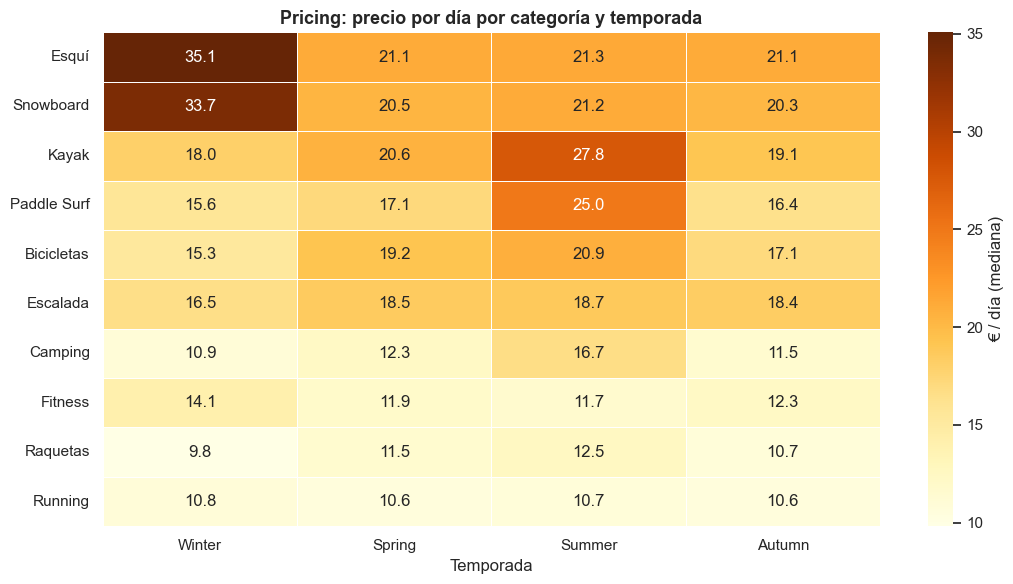

Variación estacional del precio/día (max vs min, %) — mayor = más margen de pricing dinámico:


,variacion_%
category,
Esquí,66.00
Snowboard,66.00
Paddle Surf,60.00
Kayak,54.00
Camping,53.00
Bicicletas,37.00
Raquetas,27.00
Fitness,21.00
Escalada,13.00


In [36]:
# --- Pricing: precio POR DÍA por categoría y temporada (base para pricing dinámico) ---
comp_p = fact[fact["completed"] & fact["rental_price"].notna() & fact["rental_days"].notna()].copy()
comp_p["price_per_day"] = comp_p["rental_price"] / comp_p["rental_days"]

season_order = ["Winter", "Spring", "Summer", "Autumn"]
price_season = (comp_p.pivot_table(index="category", columns="season",
                                   values="price_per_day", aggfunc="median")
                .reindex(columns=season_order))
price_season = price_season.loc[price_season.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(price_season, annot=True, fmt=".1f", cmap="YlOrBr",
            linewidths=.4, cbar_kws={"label": "€ / día (mediana)"}, ax=ax)
ax.set_title("Pricing: precio por día por categoría y temporada")
ax.set_xlabel("Temporada"); ax.set_ylabel("")
plt.tight_layout(); plt.show()

# Amplitud estacional del precio: recorrido de pricing dinámico por categoría.
spread = ((price_season.max(axis=1) / price_season.min(axis=1) - 1) * 100).round(0)
print("Variación estacional del precio/día (max vs min, %) — mayor = más margen de pricing dinámico:")
display(spread.sort_values(ascending=False).to_frame("variacion_%"))

> **Lectura (Pricing):** el precio/día **no es plano**: se mueve con la temporada y el mapa dibuja **tres perfiles** claros (referencia: mediana global ≈ **17 €/día**).
>
> | Perfil | Categorías | Pico → valle | Variación estacional |
> |--------|-----------|--------------|----------------------|
> | **Nieve (pico invierno)** | Esquí (35 €→21 €), Snowboard (34 €→20 €) | Invierno → primavera/verano | **+67 % / +69 %** |
> | **Agua y aire libre (pico verano)** | Paddle Surf (25 €), Kayak (28 €), Camping (17 €), Bicicletas | Verano → invierno | **+37 % a +60 %** |
> | **Todo el año / indoor** | Running (≈10.6 €), Escalada, Fitness, Raquetas | Casi sin curva | **+2 % a +29 %** |
>
> **Qué significa para el negocio:**
> - **El pricing dinámico ya existe y es racional:** en las categorías estacionales el precio **sube justo cuando sube la demanda** (esquí carísimo en invierno, kayak/paddle en verano). Se está capturando el *premium* de escasez —esquí en invierno cuesta **~2× la media** y snowboard casi duplica su propio precio de temporada baja.
> - **Palanca 1 · activar inventario parado:** la columna de **temporada baja** (esquí en primavera 21 €, kayak en invierno 18 €) es donde vive el stock ocioso. Un descuento off-season más agresivo es la vía para subir la **ocupación** de ese material (enlaza con **6.11 Gestión de stock**).
> - **Palanca 2 · categorías planas = pricing sin explotar:** Running (+2 %), Escalada (+13 %) y Fitness (+20 %) apenas diferencian precio. O la demanda es genuinamente aseasonal —y hacen bien en mantenerlo plano— o hay **poder de precio latente** que a resolución *estacional* no se ve (probar pricing por **día de semana / franja de fin de semana**).
>
> **Matices de método:** usamos la **mediana del precio *por día*** (no el ticket total) para neutralizar el mix de duraciones y comparar categorías de forma justa; y es **precio observado, no elasticidad** —vemos lo que se cobra, no cómo responde la demanda. Fijar el precio óptimo requeriría **experimentar** (ver el test A/B de §7.5).

### 6.11 Gestión de stock — ¿qué inventario sostiene el negocio? (análisis ABC)

> **Gestión de stock (retail):** decidir **cuánto inventario** tener de cada referencia y **cómo distribuirlo**. El **análisis ABC** (principio de Pareto) clasifica el catálogo por su peso en ingresos: **A** = pocos productos que generan ~80 % del negocio (proteger disponibilidad, ampliar stock si están saturados), **B** = siguiente ~15 %, **C** = cola larga de baja rotación (candidatos a **reducir/reubicar** para liberar capital).

Cruzamos la **curva de Pareto** de ingresos con la **clasificación de rotación** (`Infrautilizado / Normal / Saturado`) ya calculada por ocupación.

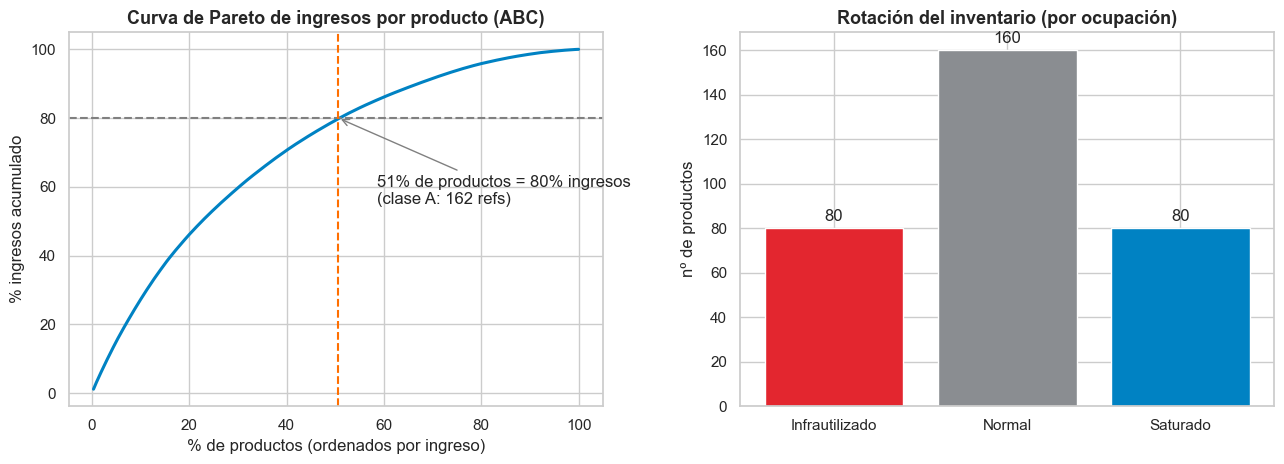

Clase A: 162 productos (51% del catálogo) concentran el 80% de los ingresos.


,n_productos
abc,
A,162
B,86
C,72


In [37]:
# --- Gestión de stock: curva de Pareto (ABC) + rotación del inventario ---
pr = product_metrics.sort_values("revenue", ascending=False).reset_index(drop=True)
pr["cum_rev_%"] = 100 * pr["revenue"].cumsum() / pr["revenue"].sum()
pr["prod_%"] = 100 * (pr.index + 1) / len(pr)
pr["abc"] = np.where(pr["cum_rev_%"] <= 80, "A",
             np.where(pr["cum_rev_%"] <= 95, "B", "C"))
n_A = int((pr["abc"] == "A").sum())
pct_A = 100 * n_A / len(pr)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.8))
# Panel 1: curva de Pareto.
ax1.plot(pr["prod_%"], pr["cum_rev_%"], color=BRAND_BLUE, lw=2.2)
ax1.axhline(80, ls="--", color="grey"); ax1.axvline(pct_A, ls="--", color=BRAND_ACCENT[2])
ax1.set_title("Curva de Pareto de ingresos por producto (ABC)")
ax1.set_xlabel("% de productos (ordenados por ingreso)"); ax1.set_ylabel("% ingresos acumulado")
ax1.annotate(f"{pct_A:.0f}% de productos = 80% ingresos\n(clase A: {n_A} refs)",
             xy=(pct_A, 80), xytext=(pct_A + 8, 55),
             arrowprops=dict(arrowstyle="->", color="grey"))
# Panel 2: rotación del inventario.
rot = (product_metrics["rotation_class"]
       .value_counts().reindex(["Infrautilizado", "Normal", "Saturado"]))
b = ax2.bar(rot.index, rot.values,
            color=["#E3262F", "#8A8D91", BRAND_BLUE])
ax2.bar_label(b, padding=3)
ax2.set_title("Rotación del inventario (por ocupación)"); ax2.set_ylabel("nº de productos")
plt.tight_layout(); plt.show()

print(f"Clase A: {n_A} productos ({pct_A:.0f}% del catálogo) concentran el 80% de los ingresos.")
display(pr["abc"].value_counts().reindex(["A", "B", "C"]).to_frame("n_productos"))

### 6.12 Comportamiento de cliente — ¿quién sostiene los ingresos?

> **Comportamiento de cliente (retail):** cómo compra/alquila cada perfil — frecuencia, gasto, recencia, fidelidad. Segmentar por comportamiento permite **priorizar la fidelización** en quien más valor aporta y **reactivar** a quien se enfría. Aquí lo miramos con el **CLRV** (*Customer Lifetime Rental Value*, ingresos acumulados por cliente) y los **segmentos** (`Occasional → Regular → Frequent → VIP`).

Comprobamos la **concentración del valor** (¿cuánto aporta el 20 % de clientes top?) y comparamos ingresos, ticket y cancelación por segmento.

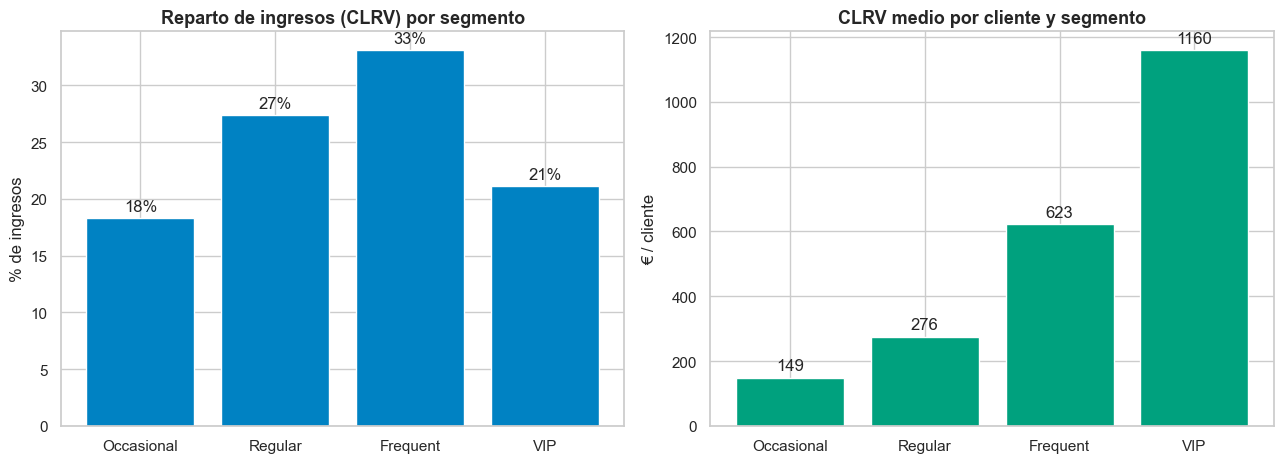

Concentración: el 20% de clientes top aporta el 56% de los ingresos (CLRV).


,customers,rev_share_pct,avg_clrv,cancel_pct
customer_segment,,,,
Occasional,14925,18.30,149.00,4.90
Regular,12034,27.40,276.00,6.51
Frequent,6442,33.10,623.00,3.49
VIP,2209,21.20,"1,160.00",2.93


In [38]:
# --- Comportamiento de cliente: concentración del CLRV y valor por segmento ---
seg_order = ["Occasional", "Regular", "Frequent", "VIP"]
cm = customer_metrics.dropna(subset=["clrv"]).copy()

# Concentración: % de ingresos que aporta el 20% de clientes con mayor CLRV.
clrv_sorted = cm["clrv"].sort_values(ascending=False).values
top20_n = max(1, int(0.20 * len(clrv_sorted)))
top20_share = 100 * clrv_sorted[:top20_n].sum() / clrv_sorted.sum()

seg = (cm.groupby("customer_segment")
       .agg(customers=("customer_id", "count"),
            total_clrv=("clrv", "sum"),
            avg_clrv=("clrv", "mean"),
            cancel_rate=("cancellation_rate", "mean"))
       .reindex(seg_order))
seg["rev_share_%"] = 100 * seg["total_clrv"] / seg["total_clrv"].sum()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.8))
b1 = ax1.bar(seg.index, seg["rev_share_%"], color=BRAND_BLUE)
ax1.bar_label(b1, fmt="%.0f%%", padding=3)
ax1.set_title("Reparto de ingresos (CLRV) por segmento"); ax1.set_ylabel("% de ingresos")
b2 = ax2.bar(seg.index, seg["avg_clrv"], color=BRAND_ACCENT[3])
ax2.bar_label(b2, fmt="%.0f", padding=3)
ax2.set_title("CLRV medio por cliente y segmento"); ax2.set_ylabel("€ / cliente")
plt.tight_layout(); plt.show()

print(f"Concentración: el 20% de clientes top aporta el {top20_share:.0f}% de los ingresos (CLRV).")
display(seg.assign(rev_share_pct=seg["rev_share_%"].round(1),
                   avg_clrv=seg["avg_clrv"].round(0),
                   cancel_pct=(100 * seg["cancel_rate"]).round(2))
        [["customers", "rev_share_pct", "avg_clrv", "cancel_pct"]])

## 7. Estadística inferencial

Pasamos de *"se ve una relación"* a **cuantificarla y contrastarla** con técnicas estadísticas aplicadas al negocio:

- **Correlaciones con significación** (§7.1)
- **Regresión de precio — OLS** (§7.2) y **de cancelación — Logit** (§7.3)
- **Intervalos de confianza** para diferencias de proporciones (§7.4)
- **Test A/B** — experimentación controlada (§7.5)
- **Análisis de cohortes** — retención de clientes (§7.6)
- **Detección de anomalías** — vigilancia de datos y negocio (§7.7)

Cada apartado incluye una **explicación breve de la técnica** y su **lectura de negocio**.

### 7.1 Correlaciones con significación estadística

In [39]:
def corr_test(x, y, data):
    d = data[[x, y]].dropna()
    r, p = stats.pearsonr(d[x], d[y])
    rho, p2 = stats.spearmanr(d[x], d[y])
    return {"par": f"{x} ~ {y}", "n": len(d), "pearson_r": round(r, 3),
            "p_value": f"{p:.1e}", "spearman_rho": round(rho, 3)}


pairs = pd.DataFrame([
    corr_test("product_age", "maintenance_cost", fact),
    corr_test("rental_days", "rental_price", fact),
    corr_test("reservation_lead_time", "review_score", fact),
    corr_test("product_age", "review_score", fact),
])
display(pairs)

,par,n,pearson_r,p_value,spearman_rho
0,product_age ~ maintenance_cost,171613,0.14,0.0e+00,0.09
1,rental_days ~ rental_price,168102,0.68,0.0e+00,0.85
2,reservation_lead_time ~ review_score,111165,-0.15,0.0e+00,-0.12
3,product_age ~ review_score,111165,-0.48,0.0e+00,-0.48


### 7.2 Modelo de precio (OLS) — ¿qué explica el `rental_price`?

> **¿Qué es OLS?** *Ordinary Least Squares* (mínimos cuadrados ordinarios) es la **regresión lineal** clásica: modela una variable **continua** —aquí el precio, en €— como una **suma ponderada** de predictores, eligiendo los coeficientes que **minimizan la suma de los errores al cuadrado** entre el precio predicho y el real. Cada coeficiente β se lee como *"manteniendo lo demás constante, un incremento de 1 unidad en ese factor cambia el precio en β €"*. La métrica **R²** indica qué proporción de la variabilidad del precio explica el modelo (0 = nada, 1 = todo). Lo usamos porque el precio es numérico y queremos **cuantificar e interpretar** cada driver (días, categoría, temporada, país), no solo predecir.

In [40]:
model_df = fact[fact["completed"] & fact["rental_price"].notna()].copy()
# patsy no admite pd.NA (dtype string): pasamos a object y descartamos nulos del modelo.
for c in ["category", "season", "store_country"]:
    model_df[c] = model_df[c].astype(object)
model_df = model_df.dropna(
    subset=["rental_days", "rental_price", "category", "season", "store_country"])
ols = smf.ols(
    "rental_price ~ rental_days + C(category) + C(season) + C(store_country)",
    data=model_df).fit()
print(ols.summary().tables[0])
print(f"\nR² = {ols.rsquared:.3f} · N = {int(ols.nobs):,}")

# Coeficientes más relevantes (efecto sobre el precio, €).
coefs = (ols.params.to_frame("coef")
         .join(ols.conf_int().rename(columns={0: "ci_low", 1: "ci_high"}))
         .join(ols.pvalues.to_frame("p_value")))
print("\nDrivers de precio (selección):")
display(coefs.loc[["rental_days"] +
                  [c for c in coefs.index if c.startswith("C(category)")]].round(3))

                            OLS Regression Results                            
Dep. Variable:           rental_price   R-squared:                       0.757
Model:                            OLS   Adj. R-squared:                  0.757
Method:                 Least Squares   F-statistic:                 2.553e+04
Date:                Sun, 20 Sep 2026   Prob (F-statistic):               0.00
Time:                        16:15:17   Log-Likelihood:            -7.5866e+05
No. Observations:              155641   AIC:                         1.517e+06
Df Residuals:                  155621   BIC:                         1.518e+06
Df Model:                          19                                         
Covariance Type:            nonrobust                                         

R² = 0.757 · N = 155,641

Drivers de precio (selección):


,coef,ci_low,ci_high,p_value
rental_days,19.53,19.43,19.62,0.00
C(category)[T.Camping],-25.38,-26.09,-24.66,0.00
C(category)[T.Escalada],-1.78,-2.44,-1.13,0.00
C(category)[T.Esquí],62.98,62.18,63.77,0.00
C(category)[T.Fitness],-47.32,-48.07,-46.57,0.00
C(category)[T.Kayak],14.48,13.76,15.21,0.00
C(category)[T.Paddle Surf],6.93,6.19,7.67,0.00
C(category)[T.Raquetas],-22.16,-22.81,-21.52,0.00
C(category)[T.Running],-15.83,-16.48,-15.18,0.00
C(category)[T.Snowboard],57.58,56.76,58.40,0.00


> **Insight (OLS):** cada **día adicional** de alquiler añade un incremento de precio
> estable y muy significativo, y las categorías de **nieve** llevan el mayor *premium*
> respecto a la base. El modelo explica una parte alta de la varianza → el pricing actual
> es **coherente y predecible**, buena base para automatizarlo.

### 7.3 Modelo de cancelación (Logit) — ¿quién cancela y por qué?

> **¿Qué es Logit?** La **regresión logística** modela una variable **binaria** (cancela = 1 / no cancela = 0). En lugar de un número continuo, predice la **probabilidad** de que ocurra el evento, usando la función *logit* para mantener el resultado entre 0 y 1. Sus coeficientes se interpretan mejor como **odds ratios** (`exp(β)`): un valor **> 1** aumenta las probabilidades de cancelar y **< 1** las reduce (p. ej. un OR de 0.7 = un 30 % menos de *odds* de cancelar). Lo usamos porque la cancelación es un sí/no —donde OLS no aplica— y el *odds ratio* traduce el modelo a lenguaje de negocio.

In [41]:
logit_df = fact.copy()
logit_df["cancelled_int"] = logit_df["cancelled"].astype(int)
for c in ["membership_level", "customer_segment"]:
    logit_df[c] = logit_df[c].astype(object)
logit_df = logit_df.dropna(
    subset=["reservation_lead_time", "membership_level", "customer_segment"])
logit = smf.logit(
    "cancelled_int ~ reservation_lead_time + C(membership_level) + C(customer_segment)",
    data=logit_df).fit(disp=False)

odds = np.exp(logit.params).to_frame("odds_ratio")
odds = odds.join(np.exp(logit.conf_int()).rename(columns={0: "or_low", 1: "or_high"}))
odds["p_value"] = logit.pvalues
print("Odds ratios de cancelación (>1 sube prob., <1 la baja):")
display(odds.round(3))

Odds ratios de cancelación (>1 sube prob., <1 la baja):


,odds_ratio,or_low,or_high,p_value
Intercept,0.05,0.04,0.05,0.00
C(membership_level)[T.Gold],0.54,0.49,0.60,0.00
C(membership_level)[T.Premium],0.51,0.47,0.55,0.00
C(membership_level)[T.Standard],1.01,0.96,1.06,0.73
C(customer_segment)[T.Occasional],1.82,1.70,1.95,0.00
C(customer_segment)[T.Regular],1.78,1.68,1.89,0.00
C(customer_segment)[T.VIP],1.00,0.92,1.08,0.97
reservation_lead_time,1.01,1.01,1.01,0.00


> **Insight (Logit):** ser socio **Premium/Gold** reduce de forma significativa la
> probabilidad de cancelar (odds ratio < 1), mientras un **lead time largo** la aumenta
> (más margen para arrepentirse). Palancas claras: **empujar membresía** y **acortar la
> ventana reserva–uso** (recordatorios, prepago parcial).

### 7.4 Intervalo de confianza — ¿cancelan menos los socios de pago?

In [42]:
paid = fact["membership_level"].isin(["Premium", "Gold"])
grp = pd.DataFrame({"paid": paid, "cancelled": fact["cancelled"].astype(int)})
counts = grp.groupby("paid")["cancelled"].agg(["sum", "count"])

# Test de dos proporciones + IC de cada grupo (Wilson).
z, pval = proportions_ztest(counts["sum"].values, counts["count"].values)
for is_paid in [True, False]:
    lo, hi = proportion_confint(counts.loc[is_paid, "sum"],
                                counts.loc[is_paid, "count"], method="wilson")
    label = "Premium/Gold" if is_paid else "Basic/Standard"
    rate = counts.loc[is_paid, "sum"] / counts.loc[is_paid, "count"]
    print(f"{label:<14} cancel rate = {rate:6.3%}  IC95% [{lo:.3%}, {hi:.3%}]")
print(f"\nDiferencia de proporciones: z = {z:.2f}, p-value = {pval:.2e}")

Premium/Gold   cancel rate = 3.025%  IC95% [2.908%, 3.146%]
Basic/Standard cancel rate = 7.701%  IC95% [7.531%, 7.875%]

Diferencia de proporciones: z = 42.30, p-value = 0.00e+00


> **Insight (IC):** la diferencia es **estadísticamente significativa** (p ≪ 0.05) y
> los intervalos de confianza **no se solapan**: convertir a un cliente a Premium/Gold
> reduce su cancelación de forma real, no por azar. Esto **cuantifica el ROI** de la
> membresía en términos de ingresos protegidos.

### 7.5 Test A/B — experimentación controlada sobre el canal

> **¿Qué es un test A/B?** Un **experimento controlado** que compara dos variantes —**A (control)** y **B (variante)**— sobre una métrica objetivo para decidir si un cambio produce una mejora **real** y no fruto del azar. Se plantea una **hipótesis nula** (H₀: no hay diferencia), se mide el **uplift** (mejora absoluta y relativa), se contrasta con un **test de dos proporciones** (p-value < 0.05 → diferencia significativa) y se comprueba la **potencia** (probabilidad de detectar el efecto si existe). Una buena práctica es **no desplegar** cambios cuyo p-value no sea significativo (evitar falsos positivos).

Aquí lo aplicamos de forma **observacional** (no es un experimento aleatorizado, pero la mecánica del contraste es idéntica): **¿el canal `App` (variante) reduce la cancelación frente a `Online` (control)?**

In [43]:
# --- Test A/B: cancelación en App (variante) vs Online (control) ---
from statsmodels.stats.proportion import proportion_effectsize
from statsmodels.stats.power import NormalIndPower

groups = {"Control (Online)": "Online", "Variante (App)": "App"}
succ, nobs, rows = [], [], []
for label, chan in groups.items():
    s = fact.loc[fact["booking_channel"] == chan, "cancelled"]
    succ.append(int(s.sum())); nobs.append(int(s.count()))
    rows.append({"grupo": label, "cancelaciones": int(s.sum()),
                 "n": int(s.count()), "cancel_rate_%": round(100 * s.mean(), 2)})
display(pd.DataFrame(rows))

p_ctrl, p_var = succ[0] / nobs[0], succ[1] / nobs[1]
z, pval = proportions_ztest(succ, nobs)
abs_uplift = p_var - p_ctrl
rel_uplift = abs_uplift / p_ctrl
es = proportion_effectsize(p_var, p_ctrl)
power = NormalIndPower().solve_power(effect_size=abs(es), nobs1=nobs[1],
                                     alpha=0.05, ratio=nobs[0] / nobs[1])

print(f"Cancelación  ·  Control (Online) = {p_ctrl:.2%}   Variante (App) = {p_var:.2%}")
print(f"Uplift  ·  absoluto = {abs_uplift * 100:+.2f} pp   relativo = {rel_uplift:+.1%}")
print(f"Contraste  ·  z = {z:.2f}   p-value = {pval:.3f}   potencia ≈ {power:.0%}")
if pval < 0.05:
    print("Decisión A/B → SIGNIFICATIVO: la diferencia es real, el canal influye en la cancelación.")
else:
    print("Decisión A/B → NO significativo: no hay evidencia de que el canal cambie la "
          "cancelación; no desplegaríamos el cambio (posible falso positivo).")

,grupo,cancelaciones,n,cancel_rate_%
0,Control (Online),4592,83036,5.53
1,Variante (App),2636,47538,5.55


Cancelación  ·  Control (Online) = 5.53%   Variante (App) = 5.55%
Uplift  ·  absoluto = +0.01 pp   relativo = +0.3%
Contraste  ·  z = -0.11   p-value = 0.910   potencia ≈ 5%
Decisión A/B → NO significativo: no hay evidencia de que el canal cambie la cancelación; no desplegaríamos el cambio (posible falso positivo).


### 7.6 Análisis de cohortes — retención de clientes

> **¿Qué es un análisis de cohortes?** Agrupa a los clientes por su **periodo de adquisición** (aquí, el **mes de su primer alquiler**) y sigue su comportamiento **mes a mes** desde entonces. La **matriz de retención** muestra, para cada cohorte, qué **% de sus clientes sigue activo** N meses después. Separa el efecto *"cuándo entró el cliente"* del efecto *"cuánto tiempo lleva"*, y revela si el negocio **fideliza** (retención que se estabiliza) o **gotea** (cae a cero), además de patrones **estacionales** de reactivación.

Construimos cohortes por mes de primer alquiler y medimos la retención en la ventana observada (enero de 2022 a julio de 2026).

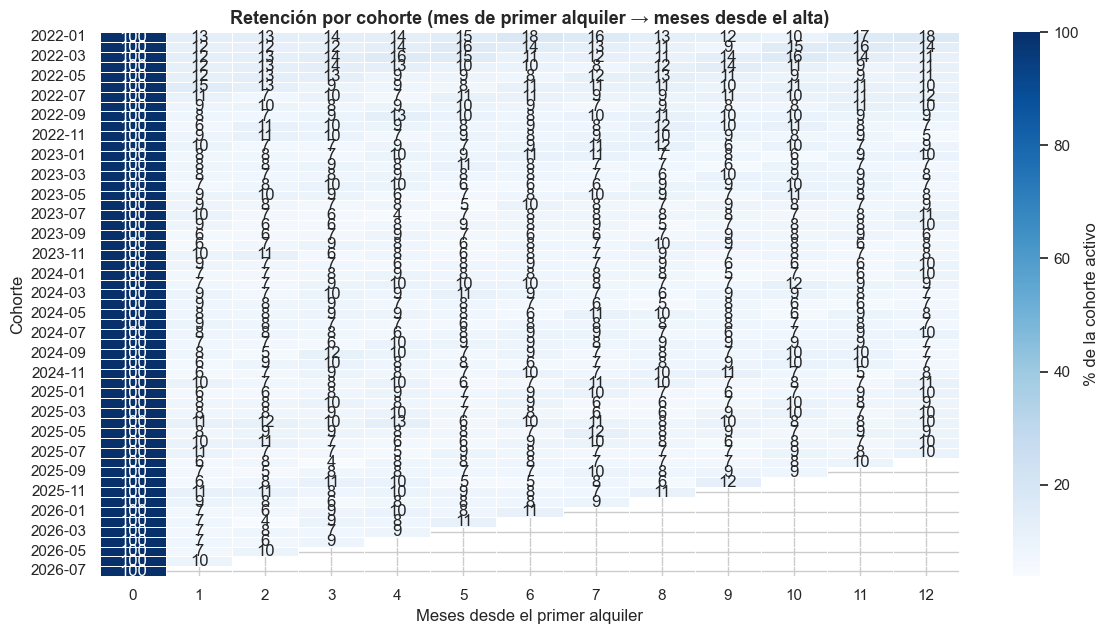

Retención media a 1 mes: 9% · el resto reaparece de forma estacional (alquiler = compra puntual, no suscripción).


In [44]:
# --- Análisis de cohortes: retención por mes de primer alquiler ---
ev = fact[["customer_id", "rental_date"]].dropna().copy()
ev["order_m"] = ev["rental_date"].dt.to_period("M")
cohort = ev.groupby("customer_id")["order_m"].min().rename("cohort")
ev = ev.join(cohort, on="customer_id")
ev["offset"] = ((ev["order_m"].dt.year - ev["cohort"].dt.year) * 12
                + (ev["order_m"].dt.month - ev["cohort"].dt.month))

cohort_sizes = ev.groupby("cohort")["customer_id"].nunique()
active = ev.groupby(["cohort", "offset"])["customer_id"].nunique().unstack("offset")
retention = active.div(cohort_sizes, axis=0) * 100
retention = retention.iloc[:, :13]                 # primeros 12 meses de vida
retention.index = retention.index.astype(str)

fig, ax = plt.subplots(figsize=(12, 6.5))
sns.heatmap(retention, annot=True, fmt=".0f", cmap="Blues",
            cbar_kws={"label": "% de la cohorte activo"}, linewidths=.4, ax=ax)
ax.set_title("Retención por cohorte (mes de primer alquiler → meses desde el alta)")
ax.set_xlabel("Meses desde el primer alquiler"); ax.set_ylabel("Cohorte")
plt.tight_layout(); plt.show()

m1 = retention.iloc[:, 1].mean()
print(f"Retención media a 1 mes: {m1:.0f}% · el resto reaparece de forma estacional "
      f"(alquiler = compra puntual, no suscripción).")

### 7.7 Detección de anomalías — vigilancia de datos y negocio

> **¿Qué es la detección de anomalías?** Identificar de forma automática puntos que se **desvían del patrón esperado** — un pico o caída anómala de ingresos, un producto con métricas fuera de rango. Sirve para **monitorización** (alertar de errores de datos o incidencias de negocio) y para **priorizar** dónde mirar. Usamos dos enfoques complementarios:
> - **Univariante robusto (MAD):** sobre la serie semanal de ingresos, señalamos para revisión las semanas cuyo residuo respecto a la tendencia local (mediana móvil) supera un **z-score robusto** (basado en la *mediana* y la *desviación absoluta mediana*, insensibles a los propios outliers). Umbral |z| > 5.
> - **Multivariante (Isolation Forest):** detecta productos atípicos por la **combinación** de ocupación, margen, mantenimiento y cancelación (opcional; requiere `scikit-learn`).

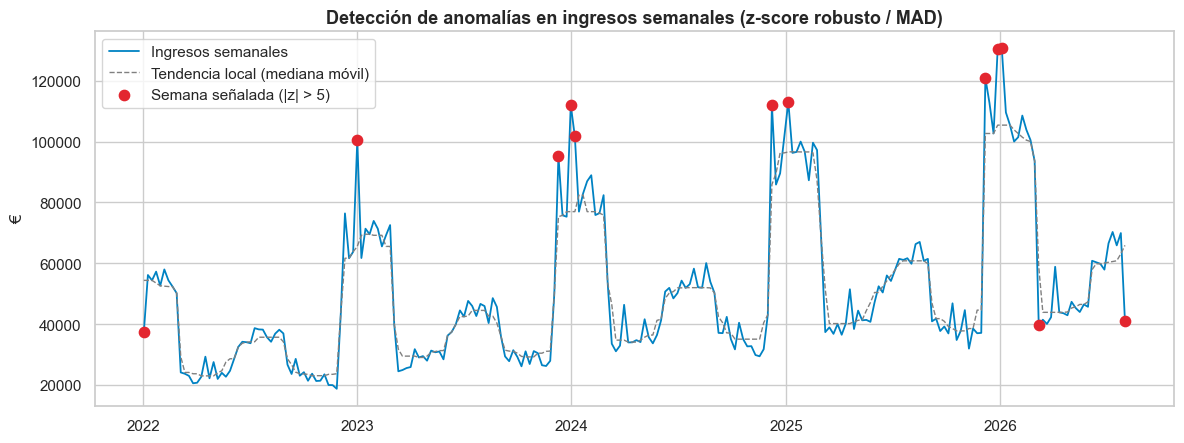

Semanas señaladas para revisión (|z| robusto > 5): 12 de 240


,revenue,robust_z
rental_date,,
2022-01-02,"37,253.90",-5.30
2023-01-01,"100,424.50",10.90
2023-12-10,"95,320.70",6.20
2023-12-31,"112,023.30",10.90
2024-01-07,"101,696.60",7.70
2024-12-08,"112,049.60",8.20
2025-01-05,"113,073.70",5.10
2025-12-07,"120,932.90",5.70
2025-12-28,"130,452.60",7.80



Isolation Forest (multivariante): 10 productos atípicos por la combinación de ocupación/margen/mantenimiento/cancelación.


,product_name,category,occupancy_rate,margin,maintenance_ratio,cancellation_rate
3,Corsa E-Bike 17,Bicicletas,0.03,-0.64,1.64,0.05
22,Terrano Trail 16,Bicicletas,0.03,-0.32,1.32,0.06
74,Veloq Trail 48,Bicicletas,0.03,-0.09,1.09,0.04
91,Corsa Trail 25,Bicicletas,0.03,-0.39,1.39,0.06
161,Veloq Gravel 69,Bicicletas,0.03,-0.10,1.10,0.06
194,Terrano MTB 01,Bicicletas,0.03,0.21,0.79,0.08
205,Ferra Home 70,Fitness,0.08,0.39,0.61,0.07
241,Corpus Weights 46,Fitness,0.10,0.77,0.23,0.03


In [45]:
# --- Detección de anomalías (1): univariante robusto sobre ingresos semanales ---
wk = (fact[fact["completed"]].set_index("rental_date")["revenue"]
      .resample("W").sum().rename("revenue").to_frame())
wk["baseline"] = wk["revenue"].rolling(13, center=True, min_periods=1).median()
resid = wk["revenue"] - wk["baseline"]
mad = (resid - resid.median()).abs().median()
wk["robust_z"] = 0.6745 * (resid - resid.median()) / (mad if mad else 1.0)
wk["anomaly"] = wk["robust_z"].abs() > 5.0

fig, ax = plt.subplots(figsize=(12, 4.6))
ax.plot(wk.index, wk["revenue"], color=BRAND_BLUE, lw=1.3, label="Ingresos semanales")
ax.plot(wk.index, wk["baseline"], color="grey", lw=1.0, ls="--", label="Tendencia local (mediana móvil)")
an = wk[wk["anomaly"]]
ax.scatter(an.index, an["revenue"], color="#E3262F", zorder=5, s=55, label="Semana señalada (|z| > 5)")
ax.set_title("Detección de anomalías en ingresos semanales (z-score robusto / MAD)")
ax.set_ylabel("€"); ax.legend()
plt.tight_layout(); plt.show()
print(f"Semanas señaladas para revisión (|z| robusto > 5): {int(wk['anomaly'].sum())} de {len(wk)}")
if wk["anomaly"].any():
    display(an[["revenue", "robust_z"]].round(1))

# --- Detección de anomalías (2): multivariante con Isolation Forest (opcional) ---
try:
    from sklearn.ensemble import IsolationForest
    feats = ["occupancy_rate", "margin", "maintenance_ratio", "cancellation_rate"]
    X = product_metrics[feats].fillna(0)
    iso = IsolationForest(contamination=0.03, random_state=42).fit(X)
    flagged = product_metrics.assign(is_anomaly=(iso.predict(X) == -1))
    n_out = int(flagged["is_anomaly"].sum())
    print(f"\nIsolation Forest (multivariante): {n_out} productos atípicos por la "
          f"combinación de ocupación/margen/mantenimiento/cancelación.")
    display(flagged.loc[flagged["is_anomaly"],
            ["product_name", "category"] + feats].head(8).round(3))
except ImportError:
    print("\n(scikit-learn no disponible: se omite la detección multivariante Isolation Forest.)")

## 8. Insights consolidados

1. **La ocupación es la palanca #1, pero el mantenimiento no es gratis.** El dinero se
   pierde en **inventario ocioso**, sobre todo en categorías estacionales; y el
   mantenimiento se lleva el **27 %** del ingreso global (el **71 %** en bicicletas),
   así que no se puede tratar como un residuo.
2. **Pareto de producto.** Un grupo reducido de referencias "Saturadas" rota muy por
   encima de la media con poco stock; muchas "Infrautilizadas" inmovilizan capital.
3. **Estacionalidad estructural.** Esquí/nieve (invierno) y agua/camping (verano) dejan
   el inventario parado medio año → cross-selling estacional y pricing dinámico.
4. **Los socios cancelan menos, pero no está identificado.** Premium/Gold cancelan
   significativamente menos (validado con IC) y puntúan mejor. Ahora bien, membresía y
   segmento son casi la misma variable —el 48,7 % de los VIP son Gold y el 0 % de los
   Occasional lo es—, así que el dato **no permite separar** "ser socio reduce la
   cancelación" de "quien alquila mucho acaba siendo socio". Hay señal; no hay ROI
   demostrado todavía.
5. **El envejecimiento tiene coste doble.** Más averías y más mantenimiento, y peor
   review → existe una edad óptima de retirada de flota.
6. **El precio es explicable, que no es lo mismo que optimizable.** El OLS reconstruye
   el ticket a partir de duración, categoría, temporada y país con R² alto, pero eso
   describe **la tarifa vigente**, no cómo respondería la demanda: ningún precio se ha
   variado nunca de forma deliberada. Sirve como motor de tarificación; **no** como
   motor de pricing, que necesitaría elasticidad medida.

## 9. Recomendaciones accionables

Un informe que sólo describe no sirve para decidir. Cada recomendación de abajo es un
objeto con **seis campos obligatorios**, y la disciplina está en los campos, no en la
redacción:

| Campo | Qué exige |
|---|---|
| **Acción** | Un imperativo que alguien puede empezar el lunes, no un objetivo |
| **Por qué** | El hallazgo que la justifica, **citado con su cifra**. Si no se puede escribir citando un número del análisis, la recomendación no sale de los datos y no entra |
| **Impacto** | Cuantificado y **derivado**. Si sale de una cadena de supuestos, la cadena se escribe; si no se puede poner en euros, se dice qué desbloquea |
| **Quién** | El área que lo ejecuta. Sin dueño plausible es un deseo |
| **Esfuerzo** | Bajo / medio / alto, para poder ordenar por retorno frente a coste |
| **Se mide con** | La métrica que dirá si funcionó **y que hoy no se está mirando** |

Tres reglas más: no repetir el hallazgo en imperativo (*"el 39 % no se atribuye"* → la
acción no es "reducir el 39 %"), **no forzar una acción** cuando el hallazgo no lleva a
ninguna, y contar las recomendaciones **sobre la propia medición** como de pleno derecho.
Suelen ser las de más retorno y casi nadie las escribe: aquí, **tres de las cinco
primeras** son deuda de dato, no acciones de negocio.

> **El impacto es una estimación con los datos de este análisis, no una promesa.** Se
> declara una vez, aquí, y después no se matiza línea por línea.

La celda siguiente **deriva todas las cifras**; ninguna está escrita a mano.

In [46]:
# --- 9.1 Las cifras que sostienen cada recomendación -------------------------
# Ninguna cifra de la tabla final está escrita a mano: todas salen de aquí, sobre
# los mismos DataFrames que ha usado el resto del notebook. Es la misma derivación
# que ejecuta el informe interactivo (docs/report/05b_reco.js), de modo que las dos
# piezas no pueden desincronizarse sin que se note.

YEARS = PERIOD_DAYS / 365.25
AMORT_LIFE = 5   # SUPUESTO declarado, no dato: el hecho no trae amortización

eur = lambda v: f"{v:,.0f} €".replace(",", ".")

# (a) El margen del cuadro de mando no descuenta el material ------------------
cat = (product_metrics
       .assign(capital=lambda d: d["inventory_units"] * d["purchase_price"])
       .groupby("category")
       .agg(capital=("capital", "sum"), revenue=("revenue", "sum"),
            maintenance=("maintenance", "sum")))
cat["contrib_y"]    = (cat["revenue"] - cat["maintenance"]) / YEARS
cat["amort_y"]      = cat["capital"] / AMORT_LIFE
cat["net_y"]        = cat["contrib_y"] - cat["amort_y"]
cat["margen_bruto"] = (cat["revenue"] - cat["maintenance"]) / cat["revenue"]
neg  = cat[cat["net_y"] < 0].sort_values("net_y")
peor = neg.index[0]

# (b) Referencias que pierden caja HOY: el mantenimiento supera al ingreso ----
pierde   = product_metrics[product_metrics["maintenance"] > product_metrics["revenue"]]
pierde_y = (pierde["revenue"] - pierde["maintenance"]).sum() / YEARS

# (c) Cancelación: cuánto de la fuga explica la antelación -------------------
lead        = fact[fact["reservation_lead_time"].notna()]
tasa_corta  = lead.loc[lead["reservation_lead_time"] <= 3, "cancelled"].mean()
larga       = lead[lead["reservation_lead_time"] >= 15]
n_canc      = int(larga["cancelled"].sum())
evitables   = n_canc - len(larga) * tasa_corta
recuperable = evitables * (larga.loc[larga["cancelled"], "rental_price"].sum() / n_canc) / YEARS
fuga_y      = fact.loc[fact["cancelled"], "rental_price"].sum() / YEARS

# (d) Ingreso completado que nunca llega al hecho ----------------------------
ticket       = fact.loc[fact["completed"], "rental_price"].mean()
sin_precio   = int((fact["completed"] & fact["rental_price"].isna()).sum())
no_contado_y = sin_precio * ticket / YEARS
share_no_contado = sin_precio * ticket / fact.loc[fact["completed"], "revenue"].sum()

# (e) ¿Distingue algo el ranking de cancelación por tienda? ------------------
p0    = fact["cancelled"].mean()
n_st  = fact.groupby("store_id").size()
k_st  = fact.groupby("store_id")["cancelled"].sum()
chi2  = (((k_st - n_st * p0) ** 2 / (n_st * p0)) +
         (((n_st - k_st) - n_st * (1 - p0)) ** 2 / (n_st * (1 - p0)))).sum()
gl     = len(n_st) - 1
p_hom  = 1 - stats.chi2.cdf(chi2, gl)
sd_obs = (k_st / n_st).std()
sd_exp = np.sqrt((p0 * (1 - p0) / n_st).mean())

# (f) El formato de tienda explica el € por visitante ------------------------
st = store_metrics[store_metrics["revenue_per_visitor"].notna()].copy()
fmt = st.groupby("store_size")["revenue_per_visitor"].median().sort_values(ascending=False)
st["med_fmt"] = st.groupby("store_size")["revenue_per_visitor"].transform("median")
bajo_f   = st[st["revenue_per_visitor"] < st["med_fmt"]]
brecha_y = ((bajo_f["med_fmt"] - bajo_f["revenue_per_visitor"]) * bajo_f["annual_visitors"]).sum() / YEARS
med_glob = st["revenue_per_visitor"].median()
bajo_g   = st[st["revenue_per_visitor"] < med_glob]
brecha_glob_y = ((med_glob - bajo_g["revenue_per_visitor"]) * bajo_g["annual_visitors"]).sum() / YEARS

# (g) Membresía: ¿efecto o selección? ----------------------------------------
ct      = pd.crosstab(fact["customer_segment"], fact["membership_level"], normalize="index")
alto    = fact.loc[fact["membership_level"].isin(["Premium", "Gold"]), "cancelled"]
bajo_m  = fact.loc[fact["membership_level"].isin(["Basic", "Standard"]), "cancelled"]
z_mem, _ = proportions_ztest([alto.sum(), bajo_m.sum()], [len(alto), len(bajo_m)])
coste_canc = fact.loc[fact["cancelled"], "rental_price"].sum() / fact["cancelled"].sum()
techo_y = (bajo_m.mean() - alto.mean()) * len(bajo_m) * coste_canc / YEARS

# (h) Dónde añadir stock rinde de inmediato ----------------------------------
occ = (product_metrics.assign(dias=lambda d: d["rental_days_sum"])
       .groupby("category")
       .agg(dias=("dias", "sum"), units=("inventory_units", "sum"),
            revenue=("revenue", "sum"), capital=("purchase_price", "sum")))
occ["occ"]      = occ["dias"] / (occ["units"] * PERIOD_DAYS)
occ["rev_u_y"]  = occ["revenue"] / occ["units"] / YEARS
occ["cap_u"]    = (product_metrics.assign(c=lambda d: d["inventory_units"] * d["purchase_price"])
                   .groupby("category")["c"].sum() / occ["units"])
top_occ  = occ["occ"].idxmax()
add_u    = round(occ.loc[top_occ, "units"] * 0.10)
capex    = add_u * occ.loc[top_occ, "cap_u"]
gain_y   = add_u * occ.loc[top_occ, "rev_u_y"]

print(f"Ventana {PERIOD_DAYS} días ({YEARS:.2f} años) · flota {eur(cat['capital'].sum())} de compra")
print(f"(a) al amortizar a {AMORT_LIFE} años pasan a negativo: {', '.join(neg.index)} · "
      f"peor {peor} {eur(neg.loc[peor, 'net_y'])}/año (hoy publica {neg.loc[peor,'margen_bruto']:.1%} de margen)")
print(f"(b) {len(pierde)} referencias pierden caja hoy: {eur(pierde_y)}/año")
print(f"(c) cancelación 0–3 d {tasa_corta:.2%} vs ≥15 d {larga['cancelled'].mean():.2%} · "
      f"recuperable {eur(recuperable)}/año de una fuga de {eur(fuga_y)}/año")
print(f"(d) {sin_precio} completados sin importe = {eur(no_contado_y)}/año ({share_no_contado:.1%} del ingreso)")
print(f"(e) homogeneidad entre tiendas: χ²={chi2:.1f} gl={gl} p={p_hom:.2f} · "
      f"sd observada {sd_obs:.3%} vs muestreo {sd_exp:.3%}")
print(f"(f) €/visitante mediano por formato: { {k: round(float(v), 3) for k, v in fmt.items()} } · "
      f"brecha dentro del formato {eur(brecha_y)}/año vs {eur(brecha_glob_y)}/año contra la global")
print(f"(g) cancelación socios {alto.mean():.2%} vs no socios {bajo_m.mean():.2%} (z={z_mem:.1f}) · "
      f"VIP que son Gold {ct.loc['VIP','Gold']:.1%}, Occasional que son Gold {ct.loc['Occasional','Gold']:.1%}")
print(f"(h) ampliar {top_occ} un 10 % = {add_u:.0f} uds · {eur(capex)} → {eur(gain_y)}/año")

Ventana 1672 días (4.58 años) · flota 4.556.787 € de compra
(a) al amortizar a 5 años pasan a negativo: Bicicletas, Kayak, Paddle Surf · peor Bicicletas -121.794 €/año (hoy publica 28.9% de margen)
(b) 8 referencias pierden caja hoy: -14.773 €/año
(c) cancelación 0–3 d 5.08% vs ≥15 d 6.79% · recuperable 12.053 €/año de una fuga de 163.358 €/año
(d) 3454 completados sin importe = 57.536 €/año (2.2% del ingreso)
(e) homogeneidad entre tiendas: χ²=70.5 gl=69 p=0.43 · sd observada 0.545% vs muestreo 0.556%
(f) €/visitante mediano por formato: {'Small': 0.571, 'Medium': 0.434, 'Large': 0.381, 'Flagship': 0.272} · brecha dentro del formato 240.851 €/año vs 579.215 €/año contra la global
(g) cancelación socios 3.02% vs no socios 7.70% (z=-42.3) · VIP que son Gold 48.7%, Occasional que son Gold 0.0%
(h) ampliar Fitness un 10 % = 93 uds · 38.398 € → 35.814 €/año


In [47]:
# --- 9.2 Las recomendaciones, ordenadas por retorno frente a esfuerzo --------
# Se muestran las ocho primeras. Las 22 del informe interactivo viven al final de
# cada una de sus páginas; aquí caben las que cambian la conversación.

recomendaciones = pd.DataFrame([
    dict(
        n=1, esfuerzo="bajo", quien="Finanzas · Datos",
        accion="Imputar el coste del material a cada alquiler y publicar el margen "
               "DESPUÉS de amortización.",
        por_que=f"El margen que publicamos es (ingreso − mantenimiento) / ingreso: no descuenta "
                f"el material. La flota vale {eur(cat['capital'].sum())} de compra y nadie la "
                f"amortiza contra los {eur(cat['revenue'].sum() / YEARS)}/año que ingresa.",
        impacto=f"Amortizada a {AMORT_LIFE} años, {len(neg)} categorías pasan a negativo: "
                f"{', '.join(f'{i} {eur(r.net_y)}/año' for i, r in neg.iterrows())}. Hoy {peor} "
                f"figura con un {neg.loc[peor,'margen_bruto']:.1%} de margen.",
        se_mide_con="Margen por categoría después de amortización, mensual. Hoy el cuadro de "
                    "mando enseña margen bruto de mantenimiento, que no es margen."),
    dict(
        n=2, esfuerzo="bajo", quien="Producto · Datos",
        accion="Añadir `cancellation_reason` obligatorio al cancelar, con lista cerrada.",
        por_que=f"{int(fact['cancelled'].sum()):,} cancelaciones y {eur(fuga_y)}/año que no se "
                f"facturan, y el hecho no guarda un solo campo sobre por qué.".replace(",", "."),
        impacto=f"Convierte {eur(fuga_y)}/año de fuga en un problema diagnosticable. Sin el "
                f"motivo, la única palanca que sostienen los datos es el recordatorio por "
                f"antelación, que cierra {eur(recuperable)}/año: un {recuperable/fuga_y:.0%} del agujero.",
        se_mide_con="% de cancelaciones con motivo informado. Hoy el campo no existe: se parte de 0 %."),
    dict(
        n=3, esfuerzo="medio", quien="Operaciones · Retail",
        accion="Fijar el objetivo de cada tienda contra la mediana de SU FORMATO, no contra "
               "la mediana global.",
        por_que=f"El € por visitante cae de forma monótona con el tamaño "
                f"({' · '.join(f'{k} {v:.3f}' for k, v in fmt.items())}): un ranking sin "
                f"controlar por formato pone a las grandes en el fondo por construcción.",
        impacto=f"La brecha real ({len(bajo_f)} tiendas bajo la mediana de su formato) vale "
                f"{eur(brecha_y)}/año. Contra la mediana global saldrían {eur(brecha_glob_y)}/año, "
                f"{brecha_glob_y/brecha_y:.1f}× más, y esa diferencia es artefacto del tamaño.",
        se_mide_con="€ por visitante frente a la mediana de su formato. Hoy se mira el ingreso "
                    "absoluto, que premia el tamaño."),
    dict(
        n=4, esfuerzo="bajo", quien="Datos · Finanzas",
        accion="Recuperar el importe de los alquileres completados que llegan sin "
               "`rental_price` y cuadrarlo contra contabilidad cada cierre.",
        por_que=f"{sin_precio:,} alquileres completados llegan sin importe. No son cancelaciones: "
                f"se entregó el material y se devolvió.".replace(",", "."),
        impacto=f"Al ticket de {ticket:,.2f} €, {eur(no_contado_y)}/año de ingreso facturado que "
                f"no aparece en ninguna cifra: un {share_no_contado:.1%} del total publicado de menos.",
        se_mide_con="% de completados con importe, cuadrado contra contabilidad. Hoy el nulo se "
                    "descuenta del denominador y desaparece."),
    dict(
        n=5, esfuerzo="bajo", quien="Producto · Compras",
        accion=f"Ampliar un 10 % la flota de {top_occ} antes de comprar unidades de cualquier "
               f"otra categoría.",
        por_que=f"{top_occ} alcanza el {occ.loc[top_occ,'occ']:.2%} de ocupación (la mayor del "
                f"catálogo) y rinde {occ.loc[top_occ,'rev_u_y']:,.0f} € por unidad y año.",
        impacto=f"{add_u:.0f} unidades más cuestan {eur(capex)} y, si alquilan como las actuales, "
                f"añaden {eur(gain_y)}/año: {capex/gain_y*12:.0f} meses de retorno. El «si» es el "
                f"único supuesto y lo sostiene la ocupación, no lo demuestra.",
        se_mide_con="€ por unidad y año de las referencias ampliadas. NO la ocupación media: baja "
                    "mecánicamente al añadir unidades."),
    dict(
        n=6, esfuerzo="bajo", quien="Operaciones",
        accion=f"Retirar las {len(pierde)} referencias cuyo mantenimiento ya supera a su ingreso "
               f"y sustituir la regla de retirada por edad por una de edad × coste.",
        por_que=f"{len(pierde)} referencias ({int(pierde['inventory_units'].sum())} unidades) "
                f"facturan menos de lo que cuestan de mantener.",
        impacto=f"Dejar de perder {eur(-pierde_y)}/año, sin cadena de supuestos: ingreso y "
                f"mantenimiento están los dos en el hecho.",
        se_mide_con="Nº de referencias con ratio de mantenimiento a 12 meses superior al 100 %. "
                    "Hoy se mira la tasa de averías, que no distingue una avería barata de una cara."),
    dict(
        n=7, esfuerzo="medio", quien="Pricing · Datos",
        accion="Montar una prueba de precio controlada: mismo material, dos tarifas, tiendas "
               "asignadas al azar.",
        por_que="El OLS reconstruye el precio con R² alto, pero describe la TARIFA vigente, no "
                "cómo respondería la demanda: ningún precio se ha variado nunca deliberadamente.",
        impacto="Convierte un ratio decorativo en una cifra sobre la que decidir. Sin elasticidad, "
                "cualquier propuesta de subir el precio en pico es una apuesta.",
        se_mide_con="Variación del ingreso por unidad y día ante el cambio de tarifa, a ocupación "
                    "constante. Hoy se mira el ticket medio, que se mueve con el mix de duración."),
    dict(
        n=8, esfuerzo="medio", quien="Marketing · Datos",
        accion="Antes de invertir en el programa de socios, aleatorizar la oferta de subida de "
               "nivel sobre clientes Basic de alta frecuencia y medir contra un control.",
        por_que=f"Los socios cancelan el {alto.mean():.2%} frente al {bajo_m.mean():.2%} (z={z_mem:.1f}), "
                f"pero membresía y segmento son casi la misma variable: el {ct.loc['VIP','Gold']:.1%} "
                f"de los VIP son Gold y el {ct.loc['Occasional','Gold']:.1%} de los Occasional lo es.",
        impacto=f"Si el efecto fuese causal, el techo son {eur(techo_y)}/año. Es lo que justifica "
                f"el experimento, no lo que promete el programa.",
        se_mide_con="Diferencia en cancelación y en alquileres por cliente entre el grupo tratado y "
                    "el de control, a 90 días. Hoy se mira la cancelación por nivel, que mezcla "
                    "efecto y selección."),
])

display(recomendaciones[["n", "accion", "por_que", "impacto", "quien", "esfuerzo", "se_mide_con"]]
        .rename(columns={"n": "#", "accion": "Acción", "por_que": "Por qué", "impacto": "Impacto",
                         "quien": "Quién", "esfuerzo": "Esfuerzo", "se_mide_con": "Se mide con"})
        .style.hide(axis="index")
        .set_properties(**{"text-align": "left", "vertical-align": "top",
                           "white-space": "normal", "font-size": "11px"})
        .set_table_styles([{"selector": "th",
                            "props": [("text-align", "left"), ("vertical-align", "top"),
                                      ("font-size", "11px")]}]))

#,Acción,Por qué,Impacto,Quién,Esfuerzo,Se mide con
1,Imputar el coste del material a cada alquiler y publicar el margen DESPUÉS de amortización.,El margen que publicamos es (ingreso − mantenimiento) / ingreso: no descuenta el material. La flota vale 4.556.787 € de compra y nadie la amortiza contra los 2.645.842 €/año que ingresa.,"Amortizada a 5 años, 3 categorías pasan a negativo: Bicicletas -121.794 €/año, Kayak -39.255 €/año, Paddle Surf -10.186 €/año. Hoy Bicicletas figura con un 28.9% de margen.",Finanzas · Datos,bajo,"Margen por categoría después de amortización, mensual. Hoy el cuadro de mando enseña margen bruto de mantenimiento, que no es margen."
2,"Añadir `cancellation_reason` obligatorio al cancelar, con lista cerrada.",9.497 cancelaciones y 163.358 €/año que no se facturan. y el hecho no guarda un solo campo sobre por qué.,"Convierte 163.358 €/año de fuga en un problema diagnosticable. Sin el motivo, la única palanca que sostienen los datos es el recordatorio por antelación, que cierra 12.053 €/año: un 7% del agujero.",Producto · Datos,bajo,% de cancelaciones con motivo informado. Hoy el campo no existe: se parte de 0 %.
3,"Fijar el objetivo de cada tienda contra la mediana de SU FORMATO, no contra la mediana global.",El € por visitante cae de forma monótona con el tamaño (Small 0.571 · Medium 0.434 · Large 0.381 · Flagship 0.272): un ranking sin controlar por formato pone a las grandes en el fondo por construcción.,"La brecha real (35 tiendas bajo la mediana de su formato) vale 240.851 €/año. Contra la mediana global saldrían 579.215 €/año, 2.4× más, y esa diferencia es artefacto del tamaño.",Operaciones · Retail,medio,"€ por visitante frente a la mediana de su formato. Hoy se mira el ingreso absoluto, que premia el tamaño."
4,Recuperar el importe de los alquileres completados que llegan sin `rental_price` y cuadrarlo contra contabilidad cada cierre.,3.454 alquileres completados llegan sin importe. No son cancelaciones: se entregó el material y se devolvió.,"Al ticket de 76.25 €, 57.536 €/año de ingreso facturado que no aparece en ninguna cifra: un 2.2% del total publicado de menos.",Datos · Finanzas,bajo,"% de completados con importe, cuadrado contra contabilidad. Hoy el nulo se descuenta del denominador y desaparece."
5,Ampliar un 10 % la flota de Fitness antes de comprar unidades de cualquier otra categoría.,Fitness alcanza el 8.45% de ocupación (la mayor del catálogo) y rinde 385 € por unidad y año.,"93 unidades más cuestan 38.398 € y, si alquilan como las actuales, añaden 35.814 €/año: 13 meses de retorno. El «si» es el único supuesto y lo sostiene la ocupación, no lo demuestra.",Producto · Compras,bajo,€ por unidad y año de las referencias ampliadas. NO la ocupación media: baja mecánicamente al añadir unidades.
6,Retirar las 8 referencias cuyo mantenimiento ya supera a su ingreso y sustituir la regla de retirada por edad por una de edad × coste.,8 referencias (241 unidades) facturan menos de lo que cuestan de mantener.,"Dejar de perder 14.773 €/año, sin cadena de supuestos: ingreso y mantenimiento están los dos en el hecho.",Operaciones,bajo,"Nº de referencias con ratio de mantenimiento a 12 meses superior al 100 %. Hoy se mira la tasa de averías, que no distingue una avería barata de una cara."
7,"Montar una prueba de precio controlada: mismo material, dos tarifas, tiendas asignadas al azar.","El OLS reconstruye el precio con R² alto, pero describe la TARIFA vigente, no cómo respondería la demanda: ningún precio se ha variado nunca deliberadamente.","Convierte un ratio decorativo en una cifra sobre la que decidir. Sin elasticidad, cualquier propuesta de subir el precio en pico es una apuesta.",Pricing · Datos,medio,"Variación del ingreso por unidad y día ante el cambio de tarifa, a ocupación constante. Hoy se mira el ticket medio, que se mueve con el mix de duración."
8,"Antes de invertir en el programa de socios, aleatorizar la oferta de subida de nivel sobre clientes Basic de alta frecuencia y medir con

### 9.3 Lo que el ejercicio obligó a corregir

Exigir que cada recomendación cite una cifra y traiga la métrica con la que se comprobará
tumbó tres conclusiones que el análisis venía arrastrando por intuición:

1. **El ranking de fricción por tienda ordena ruido.** Las 70 tiendas cancelan
   estadísticamente igual: el contraste de homogeneidad no rechaza (p ≈ 0,43) y la
   dispersión observada entre tiendas es **menor** que la que produciría el puro muestreo.
   La acción no es auditar a la peor: es sacar ese ranking del seguimiento operativo.
2. **La relación membresía–cancelación no está identificada.** El efecto es enorme y
   significativo, y aun así no se puede usar: membresía y segmento son casi la misma
   variable. Lo que la recomendación pide no es lanzar la campaña, es aleatorizarla.
3. **El detector de anomalías detecta la temporada.** Las semanas que superan el umbral
   robusto son todas de diciembre. Un aviso que salta cada diciembre se desactiva el
   segundo año, y entonces tampoco avisa de la caída real.

**Las recomendaciones sobre la medición ganan.** Tres de las cinco primeras —imputar el
coste del material, registrar el motivo de cancelación, recuperar los importes que no
llegan al hecho— no son acciones de negocio: son deuda de dato. Un análisis que sólo mira
el negocio nunca las escribe, y son las que desbloquean todo lo demás.

**De la recomendación al plan.** El informe interactivo lleva esto un paso más allá en su
página *Plan de flota*: en vez de dejar la política en prosa, la aplica a las 320
referencias y devuelve una acción por cada una —retirar, no reponer, renovar, ampliar,
revisar o mantener— con el euro anual que mueve. Es un motor de reglas deterministas, no
un modelo, y va sobre la **flota** y no sobre el cliente por una razón concreta: un *next
best action* de cliente necesita pares *(acción tomada, resultado)*, y ninguna de las 36
columnas de este dataset registra una acción hacia nadie.

> Las 22 recomendaciones completas, una por página, están en
> [`docs/informe.html`](https://diegoprieto23.github.io/sports-rental-analytics/informe.html).

## 10. De análisis a producto de datos

Este notebook es un **prototipo de descubrimiento**. Para convertirlo en un activo
gobernado y fiable dentro de la plataforma de Datos e IA de la compañía:

### Arquitectura Lakehouse (medallion)
- **Bronze:** ingesta cruda de `rentals/customers/products/stores` (append, inmutable).
- **Silver:** limpieza y estandarización = nuestro pipeline (`clean_rentals`,
  `canon_category`, `standardize_text`) versionado y testeado.
- **Gold / Data Mart:** tablas de métricas (`product_metrics`, `store_metrics`,
  `customer_metrics`) listas para consumo de negocio.

### Transformación y modelado — **dbt**
- Modelos `staging` (1:1 con fuente, casting/renombrado) → `intermediate` (joins/limpieza)
  → `marts` (métricas de negocio). Las funciones de este notebook se traducen a
  modelos SQL/`dbt` reutilizables.
- **Tests de calidad** en dbt: `not_null`, `unique` (PK), `accepted_values`
  (categorías canónicas), `relationships` (FK), y tests *custom* para reglas de negocio
  (review ∈ [1,5], `return_date ≥ rental_date`, precio en rango).

### Contratos de datos (**Data Contracts**)
- Esquema + expectativas + SLA acordados con el equipo productor (tipos, nulabilidad,
  dominios). Rompe el contrato → falla el pipeline, no el dashboard.

### Catálogo de métricas (**Semantic / Metrics Layer**)
- Definir *una sola vez* Occupancy, Margin, CLRV… (p. ej. dbt Semantic Layer / MetricFlow)
  para que SQL, BI y notebooks compartan la **misma verdad**.

### Consumo — **Tableau**
- Dashboards sobre las tablas Gold: cuadro de KPIs, mapa de ocupación por
  tienda/categoría, cohortes de cliente y alertas de flota a renovar.

### Ingeniería y fiabilidad
- **Git**: notebook + dbt + tests versionados; PRs con revisión.
- **CI/CD**: `dbt build` + tests en cada merge; despliegue por entornos (dev/pre/prod).
- **Orquestación**: Databricks Workflows / Airflow (ingesta → silver → gold → tests → BI).
- **Alertas automáticas**: si el **Data Trust Score** o un test cae por debajo del umbral,
  notificación (Slack/Teams) y *freshness checks* de datos.
- **Observabilidad**: linaje de datos y monitorización de métricas clave (drift de demanda).

### 10.1 (Opcional) Transformación distribuida con PySpark
Misma lógica de agregación (ingresos por categoría), expresada en Spark para volúmenes
de escala *Lakehouse*. En **Databricks** el runtime Spark ya está disponible y basta con
poner `RUN_PYSPARK = True`. En local, Spark suele requerir Java + Hadoop/winutils; por
eso la ejecución está **controlada por un flag** y protegida con `try/except`, de modo
que el notebook nunca se rompe por el entorno.

In [48]:
# Flag de control: poner a True en Databricks o en un local con Spark configurado.
RUN_PYSPARK = False

PYSPARK_SNIPPET = """
from pyspark.sql import functions as F
sdf = spark.createDataFrame(fact.loc[fact['completed'], ['category', 'revenue']].dropna())
(sdf.groupBy('category')
    .agg(F.round(F.sum('revenue'), 0).alias('revenue_eur'),
         F.count('*').alias('rentals'))
    .orderBy(F.desc('revenue_eur'))
    .show(10, truncate=False))
"""
print("Transformación PySpark equivalente (ingresos por categoría):")
print(PYSPARK_SNIPPET)

if RUN_PYSPARK:
    import os
    import sys
    os.environ.setdefault("PYSPARK_PYTHON", sys.executable)
    os.environ.setdefault("PYSPARK_DRIVER_PYTHON", sys.executable)
    try:
        from pyspark.sql import SparkSession
        from pyspark.sql import functions as F

        spark = (SparkSession.builder.master("local[*]").appName("SportsRental")
                 .config("spark.ui.enabled", "false").getOrCreate())
        spark.sparkContext.setLogLevel("ERROR")
        sdf = spark.createDataFrame(
            fact.loc[fact["completed"], ["category", "revenue"]].dropna())
        (sdf.groupBy("category")
            .agg(F.round(F.sum("revenue"), 0).alias("revenue_eur"),
                 F.count("*").alias("rentals"))
            .orderBy(F.desc("revenue_eur"))
            .show(10, truncate=False))
        spark.stop()
    except Exception as exc:
        print("Spark local no disponible:", type(exc).__name__,
              "— en Databricks corre de forma nativa sobre el cluster.")
else:
    print("RUN_PYSPARK=False → celda informativa. Actívala en Databricks o con Spark local.")

Transformación PySpark equivalente (ingresos por categoría):

from pyspark.sql import functions as F
sdf = spark.createDataFrame(fact.loc[fact['completed'], ['category', 'revenue']].dropna())
(sdf.groupBy('category')
    .agg(F.round(F.sum('revenue'), 0).alias('revenue_eur'),
         F.count('*').alias('rentals'))
    .orderBy(F.desc('revenue_eur'))
    .show(10, truncate=False))

RUN_PYSPARK=False → celda informativa. Actívala en Databricks o con Spark local.


---
### Cierre
El análisis pasa de **datos crudos con problemas de calidad** a un conjunto de
**decisiones priorizadas por impacto**: subir ocupación (inventario), automatizar precio,
proteger ingresos vía fidelización y renovar flota a tiempo. El siguiente paso es
**industrializarlo** con dbt + Lakehouse + un catálogo de métricas gobernado.